<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/RF_Coupler_Layouts_PHIDL_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## RF coupler layouts with PHIDL and GDSTK

This notebook generates six common RF and microwave coupler layouts using PHIDL-style geometry construction and exports each layout as an OASIS file through GDSTK. Each coupler section renders a layout preview and an expected response curve from an idealized lumped or transmission-line model.

The six included topologies are a resistive 6 dB splitter/combiner, a Wilkinson power divider/combiner, a coupled-line directional coupler, a branch-line 90 degree quadrature hybrid, a rat-race 180 degree hybrid, and a Lange interdigitated quadrature coupler.

The plotted responses are synthesis-level estimates. They are useful for checking qualitative behavior, port labeling, coupling targets, and bandwidth expectations before EM extraction in a solver such as Sonnet, HFSS, openEMS, or some other full-wave tool.

In [1]:
!pip install -q uv
!uv pip install --system -q numpy matplotlib phidl gdstk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 31.2 MB/s eta 0:00:00


In [2]:
"""Shared RF coupler layout, OASIS export, and response helpers."""

from pathlib import Path
from typing import Iterable

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import phidl.geometry as pg
from matplotlib.patches import Polygon
from phidl import Device

# =============================================================================
# GLOBAL CONTROL KNOBS
# =============================================================================

MPL_DPI = 250
OASIS_DIRECTORY = Path("oas_coupler_layouts")

CENTER_FREQUENCY_GHZ = 5.0
FREQUENCY_MIN_GHZ = 2.0
FREQUENCY_MAX_GHZ = 8.0
FREQUENCY_POINTS = 1201

Z0_OHM = 50.0
EPSILON_R = 3.38
SUBSTRATE_HEIGHT_UM = 508.0
ELECTRICAL_LENGTH_SCALE = 0.96

METAL_LAYER = 1
RESISTOR_LAYER = 2
AIR_BRIDGE_LAYER = 3
BOUNDARY_LAYER = 10

LAYOUT_FIGURE_SIZE_IN = (9.2, 5.8)
RESPONSE_FIGURE_SIZE_IN = (8.2, 4.8)

mpl.rcParams["figure.dpi"] = MPL_DPI
OASIS_DIRECTORY.mkdir(parents=True, exist_ok=True)


# =============================================================================
# MICROSTRIP APPROXIMATION HELPERS
# =============================================================================


def microstrip_effective_epsilon(
    width_um: float,
    height_um: float,
    epsilon_r: float,
) -> float:
    """Return the quasi-static effective permittivity of a microstrip."""
    width_height_ratio = width_um / height_um
    correction = 1.0 / np.sqrt(1.0 + 12.0 / width_height_ratio)
    return (
        0.5 * (epsilon_r + 1.0)
        + 0.5 * (epsilon_r - 1.0) * correction
    )


def microstrip_z0(
    width_um: float,
    height_um: float,
    epsilon_r: float,
) -> float:
    """Return a Hammerstad-style quasi-static microstrip impedance."""
    width_height_ratio = width_um / height_um
    epsilon_eff = microstrip_effective_epsilon(
        width_um,
        height_um,
        epsilon_r,
    )

    if width_height_ratio <= 1.0:
        argument = 8.0 / width_height_ratio + 0.25 * width_height_ratio
        return 60.0 * np.log(argument) / np.sqrt(epsilon_eff)

    denominator = (
        width_height_ratio
        + 1.393
        + 0.667 * np.log(width_height_ratio + 1.444)
    )
    return 120.0 * np.pi / (np.sqrt(epsilon_eff) * denominator)


def solve_microstrip_width(
    target_z0_ohm: float,
    height_um: float,
    epsilon_r: float,
) -> float:
    """Solve for microstrip width at a target characteristic impedance."""
    lower_um = 0.02 * height_um
    upper_um = 30.0 * height_um

    for _ in range(90):
        middle_um = 0.5 * (lower_um + upper_um)
        trial_z0 = microstrip_z0(middle_um, height_um, epsilon_r)

        if trial_z0 > target_z0_ohm:
            lower_um = middle_um
        else:
            upper_um = middle_um

    return 0.5 * (lower_um + upper_um)


def guided_quarter_wavelength_um(
    frequency_ghz: float,
    epsilon_eff: float,
) -> float:
    """Return guided quarter wavelength in micrometers."""
    c_um_per_s = 2.99792458e14
    frequency_hz = frequency_ghz * 1.0e9
    wavelength_um = c_um_per_s / (frequency_hz * np.sqrt(epsilon_eff))
    return wavelength_um / 4.0


def quarter_wave_length_for_impedance(
    characteristic_impedance_ohm: float,
) -> tuple[float, float, float]:
    """Return width, effective permittivity, and scaled quarter-wave length."""
    width_um = solve_microstrip_width(
        characteristic_impedance_ohm,
        SUBSTRATE_HEIGHT_UM,
        EPSILON_R,
    )
    epsilon_eff = microstrip_effective_epsilon(
        width_um,
        SUBSTRATE_HEIGHT_UM,
        EPSILON_R,
    )
    quarter_wave_um = guided_quarter_wavelength_um(
        CENTER_FREQUENCY_GHZ,
        epsilon_eff,
    )
    return width_um, epsilon_eff, ELECTRICAL_LENGTH_SCALE * quarter_wave_um


# =============================================================================
# GEOMETRY HELPERS
# =============================================================================


def add_rectangle(
    device: Device,
    origin_um: tuple[float, float],
    size_um: tuple[float, float],
    layer: int,
):
    """Add an axis-aligned rectangle to a PHIDL device."""
    rectangle = pg.rectangle(size=size_um, layer=layer)
    reference = device.add_ref(rectangle)
    reference.move(origin_um)
    return reference


def add_centered_line(
    device: Device,
    start_um: tuple[float, float],
    end_um: tuple[float, float],
    width_um: float,
    layer: int,
) -> None:
    """Add a rectangular line segment centered on a straight path."""
    start = np.asarray(start_um, dtype=np.float64)
    end = np.asarray(end_um, dtype=np.float64)
    tangent = end - start
    length = float(np.linalg.norm(tangent))

    if length <= 0.0:
        raise ValueError("Line segment length must be positive.")

    tangent /= length
    normal = np.array([-tangent[1], tangent[0]])
    half_width = 0.5 * width_um

    points = np.vstack(
        [
            start + half_width * normal,
            end + half_width * normal,
            end - half_width * normal,
            start - half_width * normal,
        ]
    )
    device.add_polygon(points, layer=layer)


def add_annular_sector(
    device: Device,
    center_um: tuple[float, float],
    inner_radius_um: float,
    outer_radius_um: float,
    start_deg: float,
    stop_deg: float,
    layer: int,
    point_count: int = 96,
) -> None:
    """Add an annular sector polygon to a PHIDL device."""
    theta_outer = np.deg2rad(np.linspace(start_deg, stop_deg, point_count))
    theta_inner = np.deg2rad(np.linspace(stop_deg, start_deg, point_count))
    center = np.asarray(center_um, dtype=np.float64)

    outer_points = np.column_stack(
        [
            center[0] + outer_radius_um * np.cos(theta_outer),
            center[1] + outer_radius_um * np.sin(theta_outer),
        ]
    )
    inner_points = np.column_stack(
        [
            center[0] + inner_radius_um * np.cos(theta_inner),
            center[1] + inner_radius_um * np.sin(theta_inner),
        ]
    )
    device.add_polygon(np.vstack([outer_points, inner_points]), layer=layer)


def add_port_pad(
    device: Device,
    center_um: tuple[float, float],
    size_um: tuple[float, float],
    layer: int = METAL_LAYER,
) -> None:
    """Add a port pad centered at the requested coordinate."""
    origin_um = (
        center_um[0] - 0.5 * size_um[0],
        center_um[1] - 0.5 * size_um[1],
    )
    add_rectangle(device, origin_um, size_um, layer)


def sanitize_cell_name(name: str) -> str:
    """Return a GDSTK-safe cell name."""
    cleaned = []
    for character in name:
        if character.isalnum():
            cleaned.append(character.upper())
        else:
            cleaned.append("_")

    cell_name = "".join(cleaned).strip("_")
    if len(cell_name) == 0:
        cell_name = "COUPLER"

    return cell_name[:64]


def write_device_to_oasis(
    device: Device,
    file_path: Path,
    cell_name: str,
) -> None:
    """Write PHIDL polygons into an OASIS file through GDSTK."""
    library = gdstk.Library(unit=1.0e-6, precision=1.0e-9)
    cell = library.new_cell(cell_name)
    polygons_by_spec = device.get_polygons(by_spec=True)

    for layer_spec, polygons in polygons_by_spec.items():
        if isinstance(layer_spec, tuple):
            layer, data_type = layer_spec
        else:
            layer = int(layer_spec)
            data_type = 0

        for polygon_points in polygons:
            cell.add(
                gdstk.Polygon(
                    polygon_points,
                    layer=int(layer),
                    datatype=int(data_type),
                )
            )

    file_path.parent.mkdir(parents=True, exist_ok=True)
    library.write_oas(str(file_path))


# =============================================================================
# RESPONSE MODEL HELPERS
# =============================================================================


def db20(magnitude: np.ndarray | float, floor_db: float = -100.0) -> np.ndarray:
    """Convert voltage-wave magnitude to dB with a numerical floor."""
    magnitude_array = np.asarray(magnitude, dtype=np.float64)
    floor = 10.0 ** (floor_db / 20.0)
    return 20.0 * np.log10(np.maximum(magnitude_array, floor))


def add_lossless_tline_to_y(
    y_matrix: np.ndarray,
    node_a: int,
    node_b: int,
    zc_ohm: float,
    theta_rad: float,
    loss_nepers: float = 1.0e-5,
) -> None:
    """Stamp a lossless transmission-line section into a nodal Y matrix."""
    theta = theta_rad - 1j * loss_nepers
    y11 = -1j / (zc_ohm * np.tan(theta))
    y12 = 1j / (zc_ohm * np.sin(theta))

    y_matrix[node_a, node_a] += y11
    y_matrix[node_b, node_b] += y11
    y_matrix[node_a, node_b] += y12
    y_matrix[node_b, node_a] += y12


def y_to_s_parameters(y_matrix: np.ndarray, z0_ohm: float) -> np.ndarray:
    """Convert an admittance matrix to an equal-reference S matrix."""
    identity = np.eye(y_matrix.shape[0], dtype=np.complex128)
    left = identity + z0_ohm * y_matrix
    right = identity - z0_ohm * y_matrix
    return np.linalg.solve(left.T, right.T).T


def network_response_from_tlines(
    frequency_ghz: np.ndarray,
    sections: Iterable[tuple[int, int, float, float]],
    port_count: int,
    z0_ohm: float = Z0_OHM,
) -> np.ndarray:
    """Return S matrices for ideal transmission-line networks."""
    s_matrices = []

    for frequency_value in frequency_ghz:
        ratio = frequency_value / CENTER_FREQUENCY_GHZ
        y_matrix = np.zeros((port_count, port_count), dtype=np.complex128)

        for node_a, node_b, zc_ohm, theta0_rad in sections:
            add_lossless_tline_to_y(
                y_matrix,
                node_a,
                node_b,
                zc_ohm,
                theta0_rad * ratio,
            )

        s_matrices.append(y_to_s_parameters(y_matrix, z0_ohm))

    return np.asarray(s_matrices)


def wilkinson_response(
    frequency_ghz: np.ndarray,
    z0_ohm: float = Z0_OHM,
) -> np.ndarray:
    """Return S matrices for an equal-split Wilkinson divider."""
    s_matrices = []
    port_count = 3

    for frequency_value in frequency_ghz:
        ratio = frequency_value / CENTER_FREQUENCY_GHZ
        y_matrix = np.zeros((port_count, port_count), dtype=np.complex128)
        theta = 0.5 * np.pi * ratio

        add_lossless_tline_to_y(
            y_matrix,
            0,
            1,
            np.sqrt(2.0) * z0_ohm,
            theta,
        )
        add_lossless_tline_to_y(
            y_matrix,
            0,
            2,
            np.sqrt(2.0) * z0_ohm,
            theta,
        )

        bridge_conductance = 1.0 / (2.0 * z0_ohm)
        y_matrix[1, 1] += bridge_conductance
        y_matrix[2, 2] += bridge_conductance
        y_matrix[1, 2] -= bridge_conductance
        y_matrix[2, 1] -= bridge_conductance

        s_matrices.append(y_to_s_parameters(y_matrix, z0_ohm))

    return np.asarray(s_matrices)


def resistive_star_response(
    frequency_ghz: np.ndarray,
    z0_ohm: float = Z0_OHM,
) -> np.ndarray:
    """Return constant S matrices for a matched resistive 6 dB splitter."""
    port_count = 3
    internal_node = 3
    resistor_ohm = z0_ohm / 3.0
    full_y = np.zeros((4, 4), dtype=np.float64)

    for port_index in range(port_count):
        conductance = 1.0 / resistor_ohm
        full_y[port_index, port_index] += conductance
        full_y[internal_node, internal_node] += conductance
        full_y[port_index, internal_node] -= conductance
        full_y[internal_node, port_index] -= conductance

    y_pp = full_y[:port_count, :port_count]
    y_pi = full_y[:port_count, internal_node:]
    y_ip = full_y[internal_node:, :port_count]
    y_ii = full_y[internal_node:, internal_node:]
    reduced_y = y_pp - y_pi @ np.linalg.inv(y_ii) @ y_ip
    s_matrix = y_to_s_parameters(reduced_y.astype(np.complex128), z0_ohm)
    return np.repeat(s_matrix[np.newaxis, :, :], frequency_ghz.size, axis=0)


def coupled_line_response(
    frequency_ghz: np.ndarray,
    coupling_db: float,
    isolation_floor_db: float = -34.0,
) -> dict[str, np.ndarray]:
    """Return a single-section coupled-line directional coupler estimate."""
    coupling_voltage = 10.0 ** (-coupling_db / 20.0)
    through_voltage = np.sqrt(1.0 - coupling_voltage**2)
    theta = 0.5 * np.pi * frequency_ghz / CENTER_FREQUENCY_GHZ
    denominator = through_voltage * np.cos(theta) + 1j * np.sin(theta)

    s31 = 1j * coupling_voltage * np.sin(theta) / denominator
    s21 = through_voltage / denominator
    leakage_shape = np.abs(np.cos(theta)) * np.abs(np.sin(theta))
    s41_mag = 10.0 ** (isolation_floor_db / 20.0) * leakage_shape
    s11_mag = 10.0 ** (-26.0 / 20.0) * leakage_shape

    return {
        "|S21| through": db20(np.abs(s21)),
        "|S31| coupled": db20(np.abs(s31)),
        "|S41| isolated": db20(s41_mag),
        "|S11| return": db20(s11_mag),
    }


def lange_response(
    frequency_ghz: np.ndarray,
) -> dict[str, np.ndarray]:
    """Return a broad 3 dB Lange coupler response estimate."""
    log_frequency = np.log2(frequency_ghz / CENTER_FREQUENCY_GHZ)
    ripple = 0.45 * log_frequency**2 + 0.10 * log_frequency**4
    coupled_db = -3.0103 - ripple
    through_db = -3.0103 - 0.55 * ripple
    isolation_db = -33.0 + 10.0 * np.minimum(log_frequency**2, 2.0)
    return_loss_db = -26.0 + 7.0 * np.minimum(log_frequency**2, 2.0)

    return {
        "|S21| through": through_db,
        "|S31| coupled": coupled_db,
        "|S41| isolated": isolation_db,
        "|S11| return": return_loss_db,
    }


def response_traces_from_s(
    s_matrices: np.ndarray,
    labels: dict[str, tuple[int, int]],
) -> dict[str, np.ndarray]:
    """Extract dB traces from an array of S matrices."""
    traces = {}
    for label, (row, column) in labels.items():
        traces[label] = db20(np.abs(s_matrices[:, row, column]))
    return traces


# =============================================================================
# RENDERING HELPERS
# =============================================================================


def render_layout(
    device: Device,
    title: str,
    annotations: Iterable[tuple[float, float, str]] | None = None,
    notes: str | None = None,
) -> None:
    """Render a PHIDL layout with layer-aware visual styling."""
    figure, axis = plt.subplots(figsize=LAYOUT_FIGURE_SIZE_IN)

    layer_styles = {
        METAL_LAYER: {
            "facecolor": "black",
            "edgecolor": "black",
            "alpha": 1.0,
            "linewidth": 0.6,
        },
        RESISTOR_LAYER: {
            "facecolor": "0.65",
            "edgecolor": "black",
            "alpha": 1.0,
            "linewidth": 0.8,
        },
        AIR_BRIDGE_LAYER: {
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 1.0,
            "linewidth": 1.0,
        },
        BOUNDARY_LAYER: {
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.25,
            "linewidth": 0.8,
        },
    }

    polygons_by_spec = device.get_polygons(by_spec=True)

    for layer_spec, polygons in polygons_by_spec.items():
        if isinstance(layer_spec, tuple):
            layer = int(layer_spec[0])
        else:
            layer = int(layer_spec)

        style = layer_styles.get(
            layer,
            {
                "facecolor": "none",
                "edgecolor": "black",
                "alpha": 1.0,
                "linewidth": 0.6,
            },
        )

        for points in polygons:
            axis.add_patch(Polygon(points, closed=True, **style))

    if annotations is not None:
        for x_um, y_um, label in annotations:
            axis.text(
                x_um,
                y_um,
                label,
                fontsize=8,
                ha="center",
                va="center",
                bbox={"boxstyle": "round,pad=0.2", "fc": "white", "alpha": 0.85},
            )

    if notes is not None:
        axis.text(
            0.02,
            0.98,
            notes,
            transform=axis.transAxes,
            va="top",
            ha="left",
            fontsize=8.5,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "alpha": 0.88},
        )

    axis.autoscale_view()
    axis.margins(0.08)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x position (µm)")
    axis.set_ylabel("y position (µm)")
    axis.set_title(title)
    axis.grid(True, linewidth=0.35, alpha=0.35)
    plt.show()


def render_response(
    frequency_ghz: np.ndarray,
    traces_db: dict[str, np.ndarray],
    title: str,
    y_limits_db: tuple[float, float] = (-70.0, 4.0),
) -> None:
    """Render expected S-parameter magnitude traces."""
    figure, axis = plt.subplots(figsize=RESPONSE_FIGURE_SIZE_IN)

    for label, values_db in traces_db.items():
        axis.plot(frequency_ghz, values_db, linewidth=2.0, label=label)

    axis.axvline(CENTER_FREQUENCY_GHZ, linestyle="--", linewidth=1.0)
    axis.set_xlabel("Frequency (GHz)")
    axis.set_ylabel("Magnitude (dB)")
    axis.set_title(title)
    axis.set_ylim(*y_limits_db)
    axis.grid(True, linewidth=0.35, alpha=0.35)
    axis.legend(loc="best", fontsize=8)
    plt.show()


def export_and_report(device: Device, coupler_name: str) -> Path:
    """Export a coupler device to OASIS and print its file path."""
    file_path = OASIS_DIRECTORY / f"{coupler_name}.oas"
    write_device_to_oasis(device, file_path, sanitize_cell_name(coupler_name))
    print(f"Generated: {coupler_name}")
    print(f"OASIS file: {file_path}")
    return file_path


frequency_ghz = np.linspace(
    FREQUENCY_MIN_GHZ,
    FREQUENCY_MAX_GHZ,
    FREQUENCY_POINTS,
)

feed_width_um, feed_epsilon_eff, feed_quarter_wave_um = (
    quarter_wave_length_for_impedance(Z0_OHM)
)
print("Shared design parameters")
print(f"  Center frequency: {CENTER_FREQUENCY_GHZ:.3f} GHz")
print(f"  Substrate epsilon_r: {EPSILON_R:.3f}")
print(f"  Substrate height: {SUBSTRATE_HEIGHT_UM:.1f} µm")
print(f"  50 Ω feed width: {feed_width_um:.2f} µm")
print(f"  50 Ω effective epsilon: {feed_epsilon_eff:.4f}")
print(f"  50 Ω scaled quarter-wave length: {feed_quarter_wave_um:.2f} µm")

Shared design parameters
  Center frequency: 5.000 GHz
  Substrate epsilon_r: 3.380
  Substrate height: 508.0 µm
  50 Ω feed width: 1185.90 µm
  50 Ω effective epsilon: 2.6702
  50 Ω scaled quarter-wave length: 8806.18 µm


Generated: resistive_6db_splitter_combiner
OASIS file: oas_coupler_layouts/resistive_6db_splitter_combiner.oas


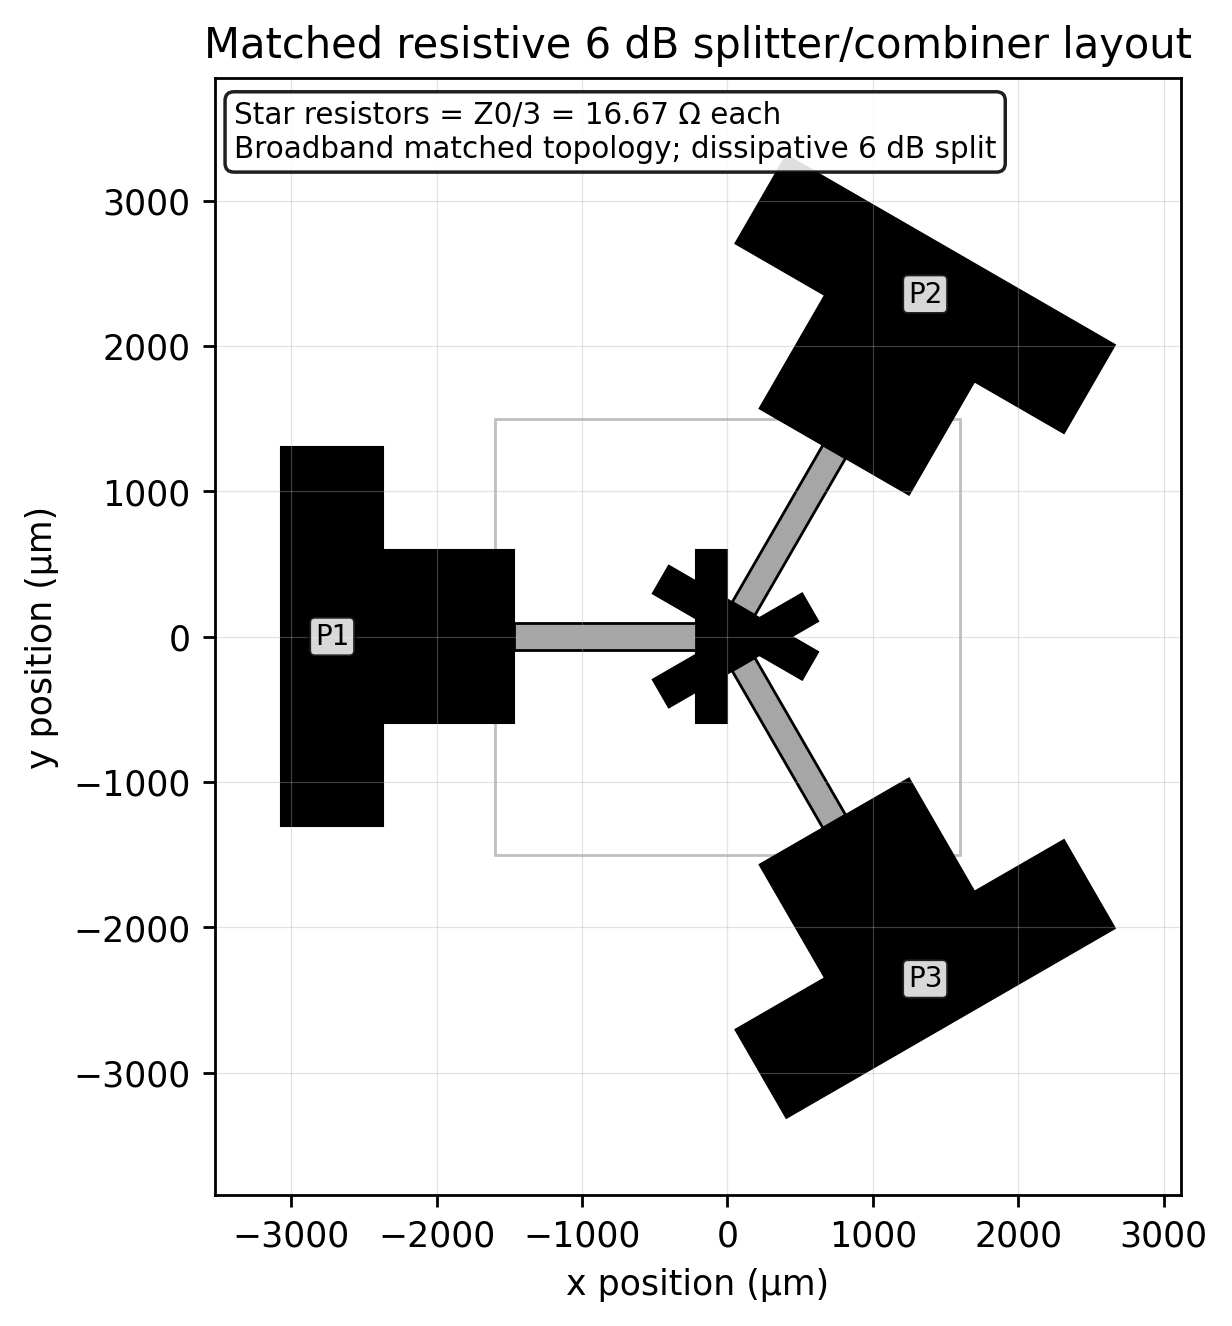

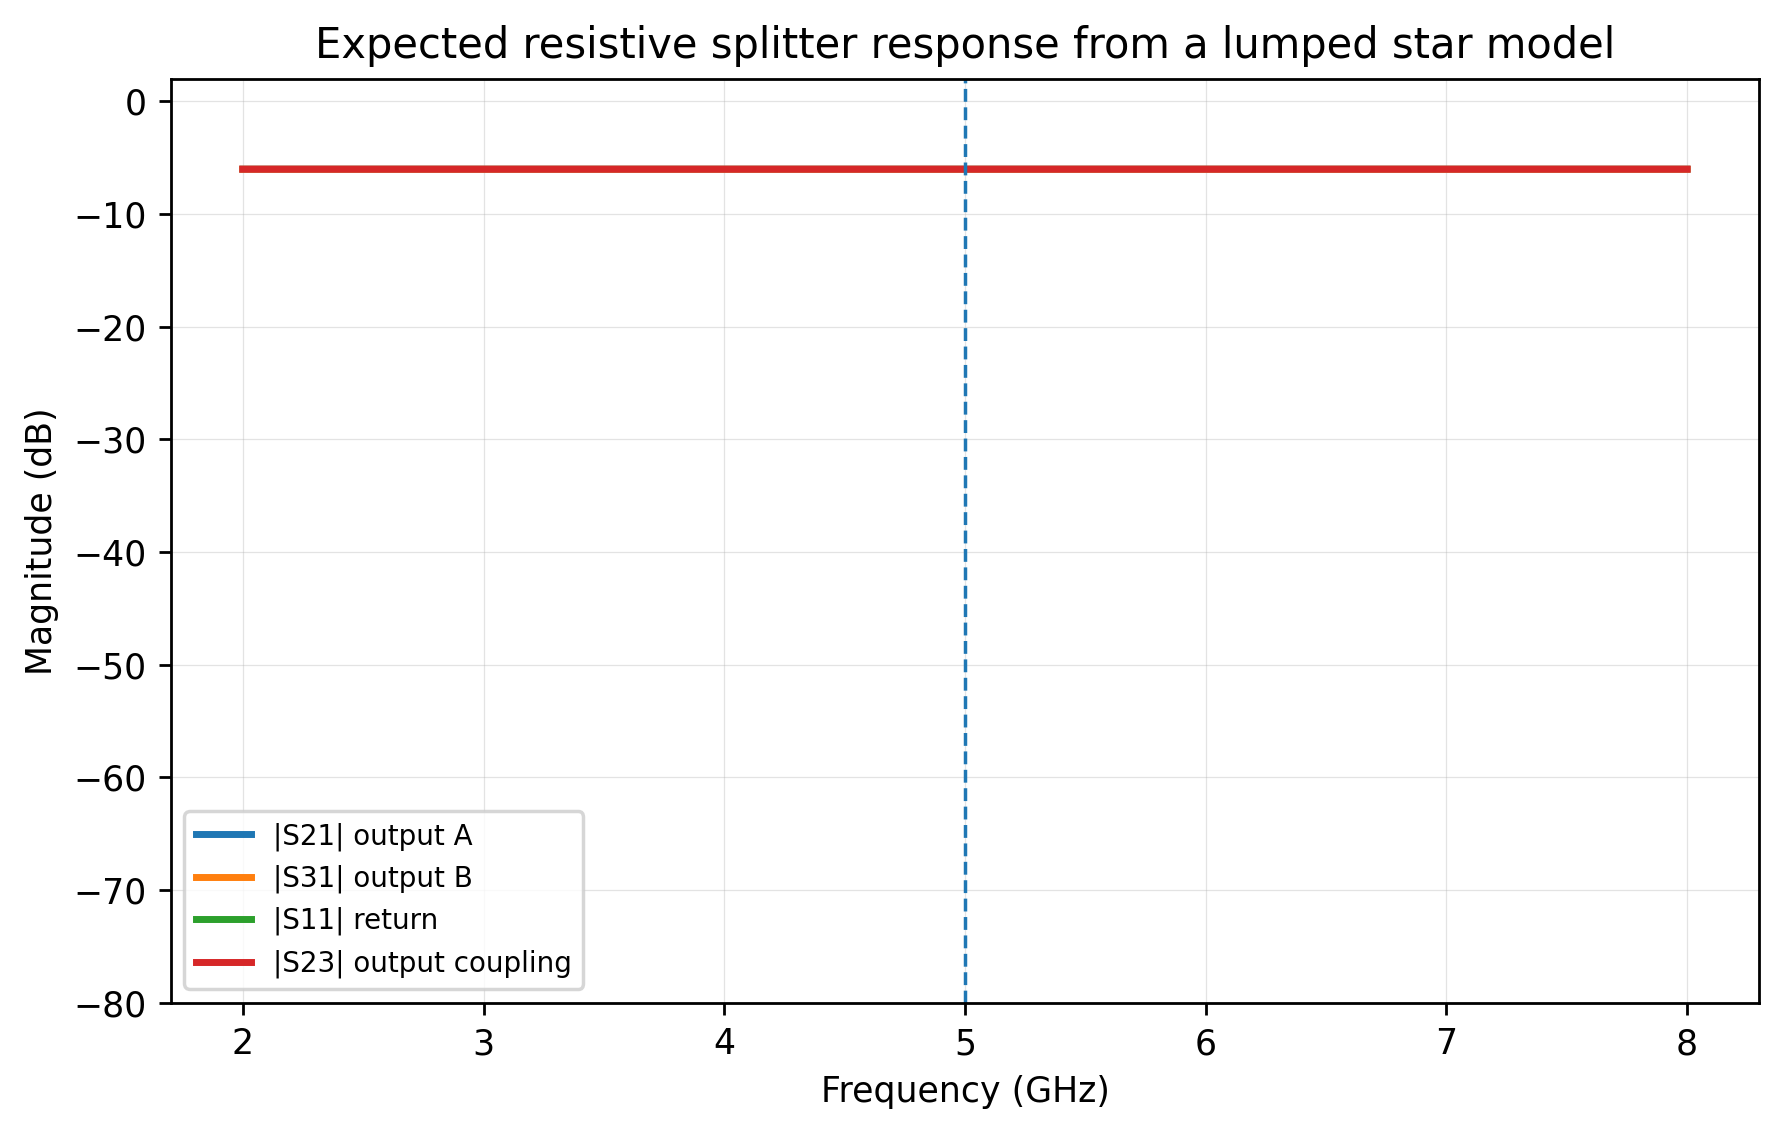

In [3]:
"""Generate a matched resistive 6 dB splitter/combiner."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "resistive_6db_splitter_combiner"
RESISTOR_LENGTH_UM = 1250.0
RESISTOR_WIDTH_UM = 180.0
METAL_STUB_LENGTH_UM = 900.0
PORT_PAD_LENGTH_UM = 700.0
PORT_PAD_WIDTH_FACTOR = 2.2


# =============================================================================
# LAYOUT
# =============================================================================


def build_resistive_splitter() -> tuple[Device, list[tuple[float, float, str]]]:
    """Build a three-resistor matched splitter/combiner layout."""
    device = Device(COUPLER_NAME)
    arm_angles_deg = [180.0, 60.0, -60.0]
    node = np.array([0.0, 0.0])
    annotations = []

    add_rectangle(
        device,
        (-1600.0, -1500.0),
        (3200.0, 3000.0),
        BOUNDARY_LAYER,
    )

    for port_index, angle_deg in enumerate(arm_angles_deg, start=1):
        angle_rad = np.deg2rad(angle_deg)
        direction = np.array([np.cos(angle_rad), np.sin(angle_rad)])
        resistor_start = node + 220.0 * direction
        resistor_end = resistor_start + RESISTOR_LENGTH_UM * direction
        metal_end = resistor_end + METAL_STUB_LENGTH_UM * direction
        pad_center = metal_end + 0.5 * PORT_PAD_LENGTH_UM * direction

        add_centered_line(
            device,
            tuple(node),
            tuple(resistor_start),
            feed_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            tuple(resistor_start),
            tuple(resistor_end),
            RESISTOR_WIDTH_UM,
            RESISTOR_LAYER,
        )
        add_centered_line(
            device,
            tuple(resistor_end),
            tuple(metal_end),
            feed_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            tuple(metal_end),
            tuple(metal_end + PORT_PAD_LENGTH_UM * direction),
            feed_width_um * PORT_PAD_WIDTH_FACTOR,
            METAL_LAYER,
        )
        annotations.append((pad_center[0], pad_center[1], f"P{port_index}"))

    return device, annotations


resistive_device, resistive_annotations = build_resistive_splitter()
export_and_report(resistive_device, COUPLER_NAME)

resistive_s = resistive_star_response(frequency_ghz)
resistive_traces = response_traces_from_s(
    resistive_s,
    {
        "|S21| output A": (1, 0),
        "|S31| output B": (2, 0),
        "|S11| return": (0, 0),
        "|S23| output coupling": (1, 2),
    },
)

render_layout(
    resistive_device,
    "Matched resistive 6 dB splitter/combiner layout",
    annotations=resistive_annotations,
    notes=(
        f"Star resistors = Z0/3 = {Z0_OHM / 3.0:.2f} Ω each\n"
        "Broadband matched topology; dissipative 6 dB split"
    ),
)
render_response(
    frequency_ghz,
    resistive_traces,
    "Expected resistive splitter response from a lumped star model",
    y_limits_db=(-80.0, 2.0),
)

Generated: wilkinson_power_divider_combiner
OASIS file: oas_coupler_layouts/wilkinson_power_divider_combiner.oas


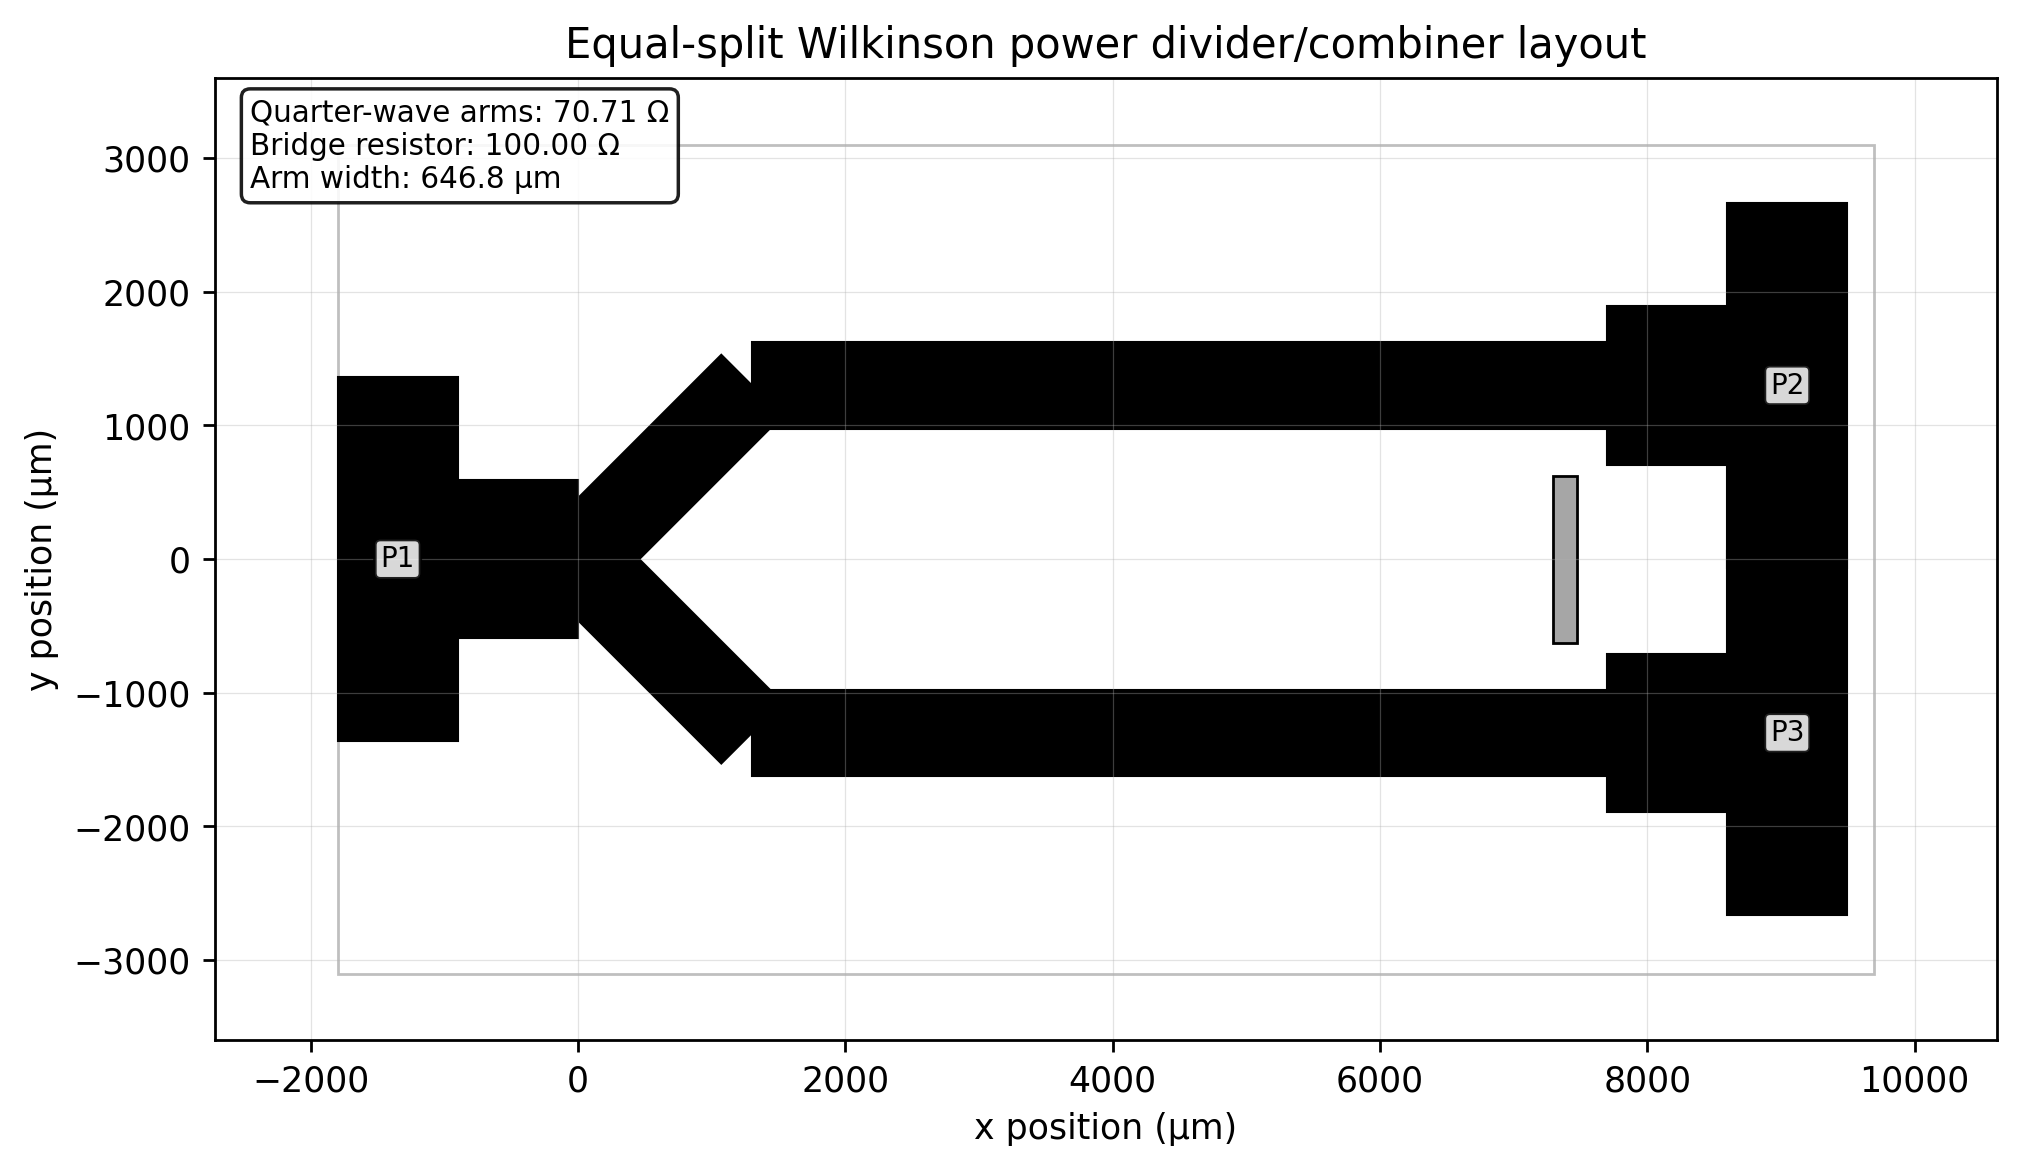

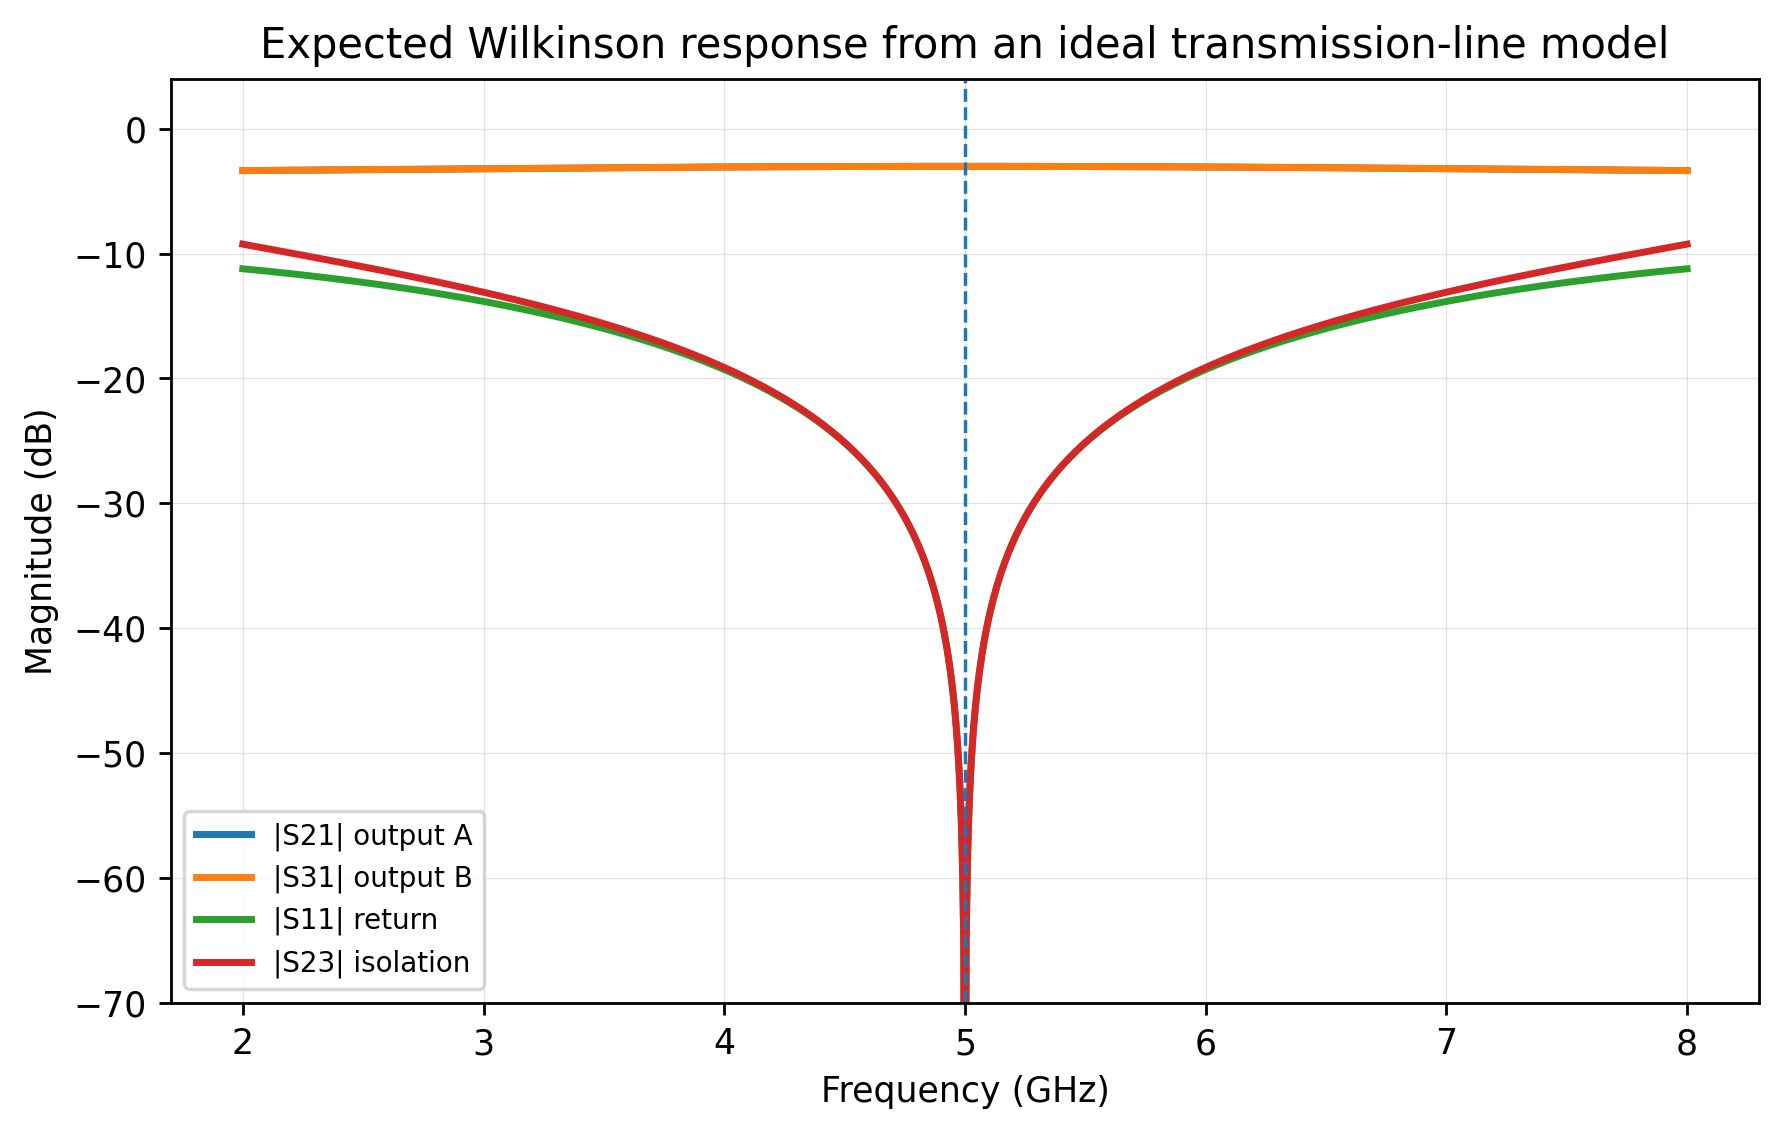

In [4]:
"""Generate an equal-split Wilkinson power divider/combiner."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "wilkinson_power_divider_combiner"
ARM_IMPEDANCE_OHM = np.sqrt(2.0) * Z0_OHM
BRIDGE_RESISTOR_OHM = 2.0 * Z0_OHM
PORT_PAD_LENGTH_UM = 900.0
PORT_PAD_WIDTH_FACTOR = 2.3
ARM_VERTICAL_SPACING_UM = 2600.0
RESISTOR_LENGTH_UM = 1250.0
RESISTOR_WIDTH_UM = 180.0


# =============================================================================
# LAYOUT
# =============================================================================


def build_wilkinson() -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build a stylized microstrip Wilkinson divider layout."""
    device = Device(COUPLER_NAME)
    arm_width_um, _, arm_length_um = quarter_wave_length_for_impedance(
        ARM_IMPEDANCE_OHM,
    )
    half_spacing_um = 0.5 * ARM_VERTICAL_SPACING_UM
    arm_horizontal_um = arm_length_um - half_spacing_um
    x_split_um = 0.0
    x_output_um = arm_horizontal_um

    add_rectangle(
        device,
        (-1800.0, -half_spacing_um - 1800.0),
        (x_output_um + 3800.0, ARM_VERTICAL_SPACING_UM + 3600.0),
        BOUNDARY_LAYER,
    )

    add_centered_line(
        device,
        (-PORT_PAD_LENGTH_UM, 0.0),
        (x_split_um, 0.0),
        feed_width_um,
        METAL_LAYER,
    )
    add_port_pad(
        device,
        (-PORT_PAD_LENGTH_UM - 0.5 * PORT_PAD_LENGTH_UM, 0.0),
        (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
    )

    for y_um in [half_spacing_um, -half_spacing_um]:
        add_centered_line(
            device,
            (x_split_um, 0.0),
            (x_split_um + half_spacing_um, y_um),
            arm_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            (x_split_um + half_spacing_um, y_um),
            (x_output_um, y_um),
            arm_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            (x_output_um, y_um),
            (x_output_um + PORT_PAD_LENGTH_UM, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_port_pad(
            device,
            (x_output_um + 1.5 * PORT_PAD_LENGTH_UM, y_um),
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )

    resistor_x_um = x_output_um - 0.35 * PORT_PAD_LENGTH_UM
    add_centered_line(
        device,
        (resistor_x_um, -0.5 * RESISTOR_LENGTH_UM),
        (resistor_x_um, 0.5 * RESISTOR_LENGTH_UM),
        RESISTOR_WIDTH_UM,
        RESISTOR_LAYER,
    )

    annotations = [
        (-1.5 * PORT_PAD_LENGTH_UM, 0.0, "P1"),
        (x_output_um + 1.5 * PORT_PAD_LENGTH_UM, half_spacing_um, "P2"),
        (x_output_um + 1.5 * PORT_PAD_LENGTH_UM, -half_spacing_um, "P3"),
    ]
    notes = (
        f"Quarter-wave arms: {ARM_IMPEDANCE_OHM:.2f} Ω\n"
        f"Bridge resistor: {BRIDGE_RESISTOR_OHM:.2f} Ω\n"
        f"Arm width: {arm_width_um:.1f} µm"
    )
    return device, annotations, notes


wilkinson_device, wilkinson_annotations, wilkinson_notes = build_wilkinson()
export_and_report(wilkinson_device, COUPLER_NAME)

wilkinson_s = wilkinson_response(frequency_ghz)
wilkinson_traces = response_traces_from_s(
    wilkinson_s,
    {
        "|S21| output A": (1, 0),
        "|S31| output B": (2, 0),
        "|S11| return": (0, 0),
        "|S23| isolation": (1, 2),
    },
)

render_layout(
    wilkinson_device,
    "Equal-split Wilkinson power divider/combiner layout",
    annotations=wilkinson_annotations,
    notes=wilkinson_notes,
)
render_response(
    frequency_ghz,
    wilkinson_traces,
    "Expected Wilkinson response from an ideal transmission-line model",
)

Generated: coupled_line_directional_coupler
OASIS file: oas_coupler_layouts/coupled_line_directional_coupler.oas


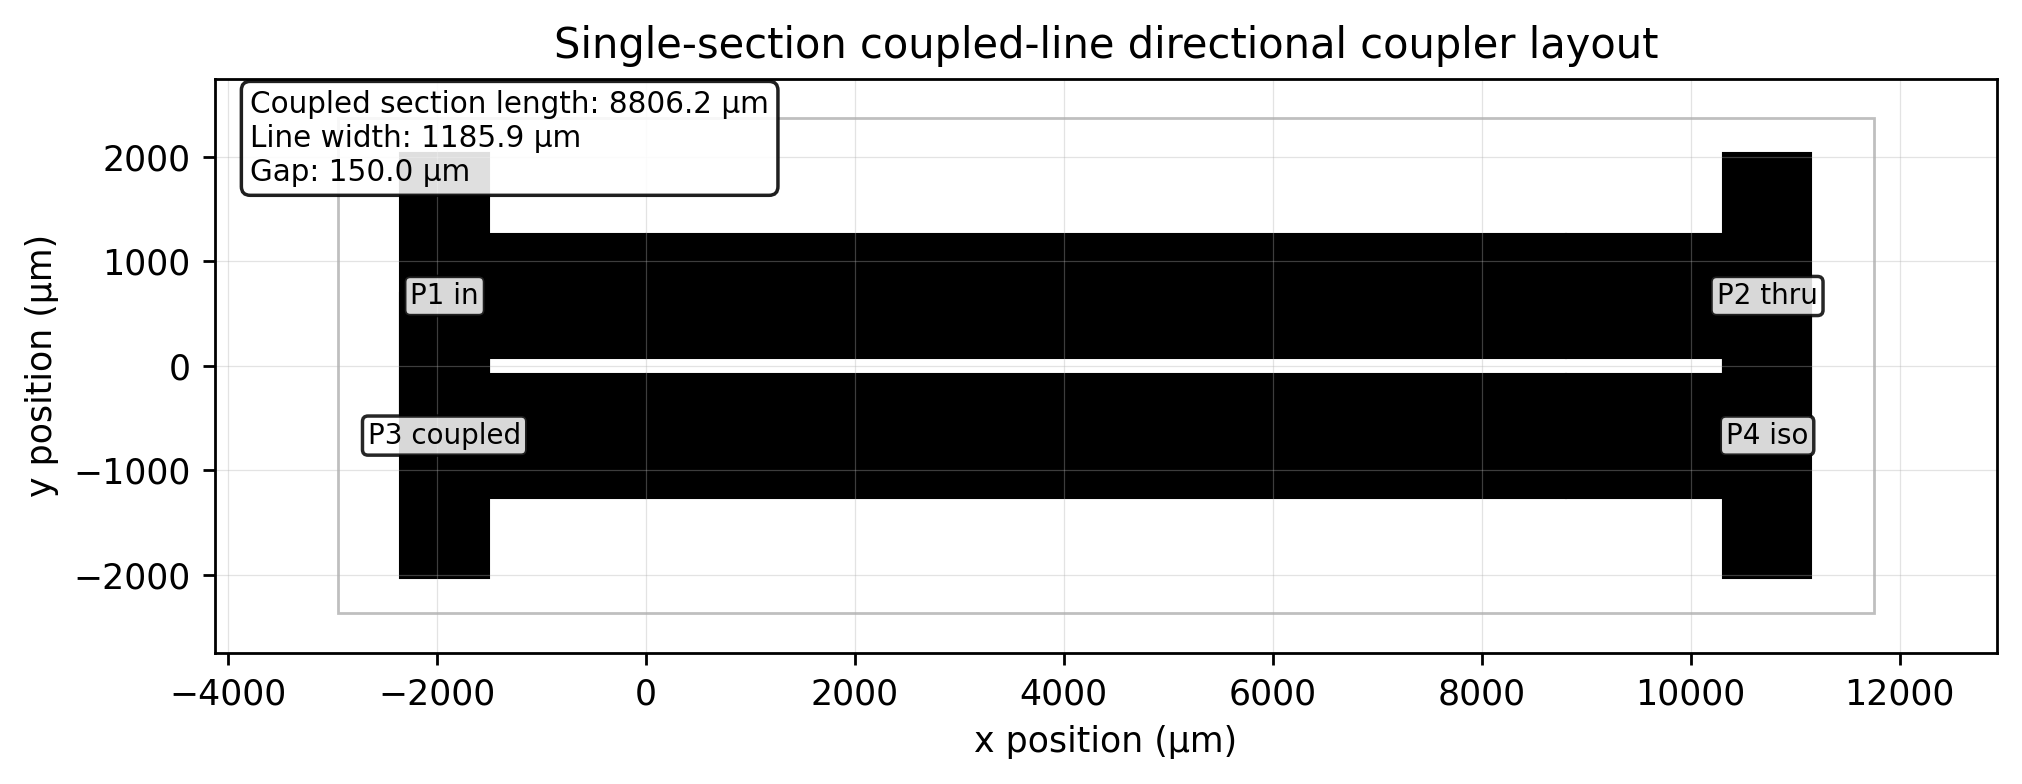

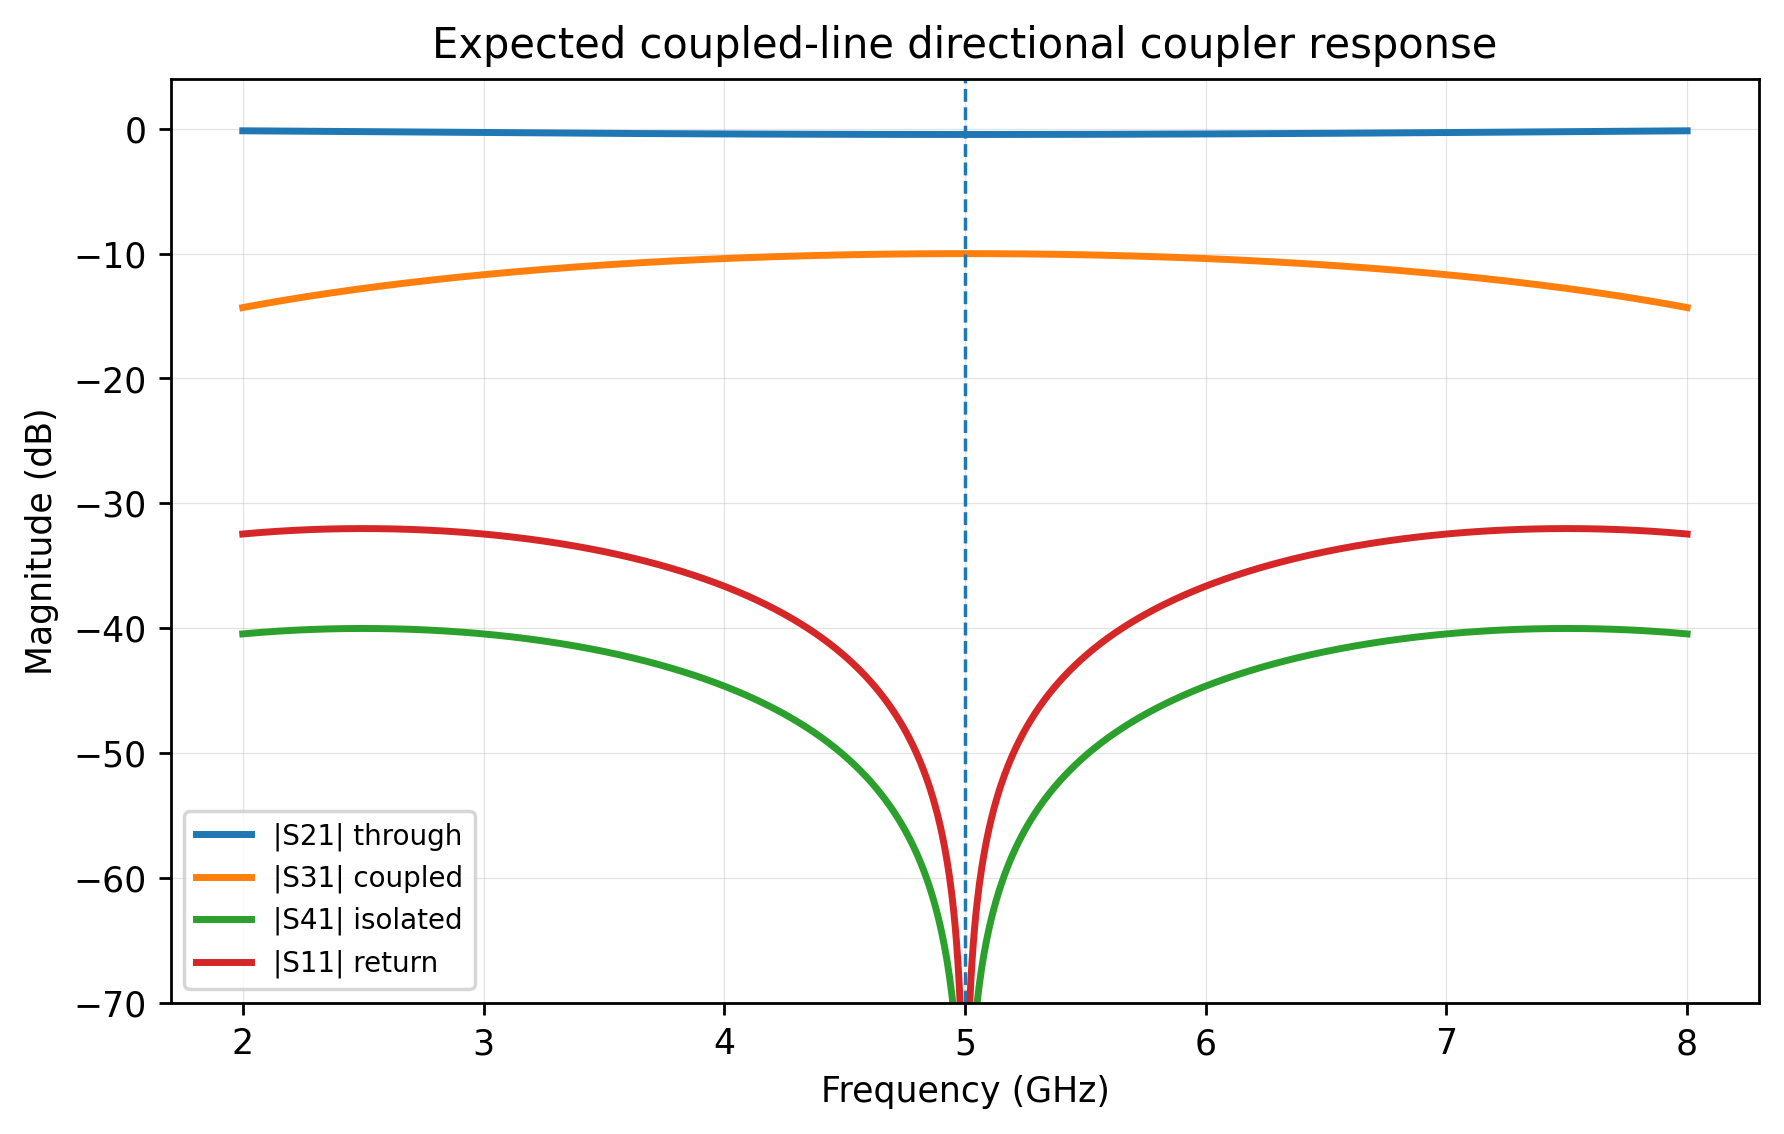

In [5]:
"""Generate a single-section coupled-line directional coupler."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "coupled_line_directional_coupler"
TARGET_COUPLING_DB = 10.0
COUPLING_GAP_UM = 150.0
PORT_EXTENSION_UM = 1500.0
PORT_PAD_LENGTH_UM = 850.0
PORT_PAD_WIDTH_FACTOR = 2.3


# =============================================================================
# LAYOUT
# =============================================================================


def build_coupled_line_coupler() -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build a quarter-wave edge-coupled directional coupler."""
    device = Device(COUPLER_NAME)
    _, _, coupled_length_um = quarter_wave_length_for_impedance(Z0_OHM)
    y_top_um = 0.5 * (feed_width_um + COUPLING_GAP_UM)
    y_bottom_um = -y_top_um
    x0_um = 0.0
    x1_um = coupled_length_um

    add_rectangle(
        device,
        (-PORT_EXTENSION_UM - PORT_PAD_LENGTH_UM - 600.0, y_bottom_um - 1700.0),
        (
            coupled_length_um
            + 2.0 * PORT_EXTENSION_UM
            + 2.0 * PORT_PAD_LENGTH_UM
            + 1200.0,
            2.0 * abs(y_bottom_um) + 3400.0,
        ),
        BOUNDARY_LAYER,
    )

    for y_um in [y_top_um, y_bottom_um]:
        add_centered_line(
            device,
            (x0_um, y_um),
            (x1_um, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            (-PORT_EXTENSION_UM, y_um),
            (x0_um, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            (x1_um, y_um),
            (x1_um + PORT_EXTENSION_UM, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_port_pad(
            device,
            (-PORT_EXTENSION_UM - 0.5 * PORT_PAD_LENGTH_UM, y_um),
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )
        add_port_pad(
            device,
            (
                x1_um + PORT_EXTENSION_UM + 0.5 * PORT_PAD_LENGTH_UM,
                y_um,
            ),
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )

    annotations = [
        (-PORT_EXTENSION_UM - 0.5 * PORT_PAD_LENGTH_UM, y_top_um, "P1 in"),
        (x1_um + PORT_EXTENSION_UM + 0.5 * PORT_PAD_LENGTH_UM, y_top_um, "P2 thru"),
        (-PORT_EXTENSION_UM - 0.5 * PORT_PAD_LENGTH_UM, y_bottom_um, "P3 coupled"),
        (x1_um + PORT_EXTENSION_UM + 0.5 * PORT_PAD_LENGTH_UM, y_bottom_um, "P4 iso"),
    ]
    notes = (
        f"Coupled section length: {coupled_length_um:.1f} µm\n"
        f"Line width: {feed_width_um:.1f} µm\n"
        f"Gap: {COUPLING_GAP_UM:.1f} µm"
    )
    return device, annotations, notes


coupled_line_device, coupled_line_annotations, coupled_line_notes = (
    build_coupled_line_coupler()
)
export_and_report(coupled_line_device, COUPLER_NAME)

coupled_line_traces = coupled_line_response(
    frequency_ghz,
    TARGET_COUPLING_DB,
)
render_layout(
    coupled_line_device,
    "Single-section coupled-line directional coupler layout",
    annotations=coupled_line_annotations,
    notes=coupled_line_notes,
)
render_response(
    frequency_ghz,
    coupled_line_traces,
    "Expected coupled-line directional coupler response",
)

Generated: branch_line_quadrature_hybrid
OASIS file: oas_coupler_layouts/branch_line_quadrature_hybrid.oas


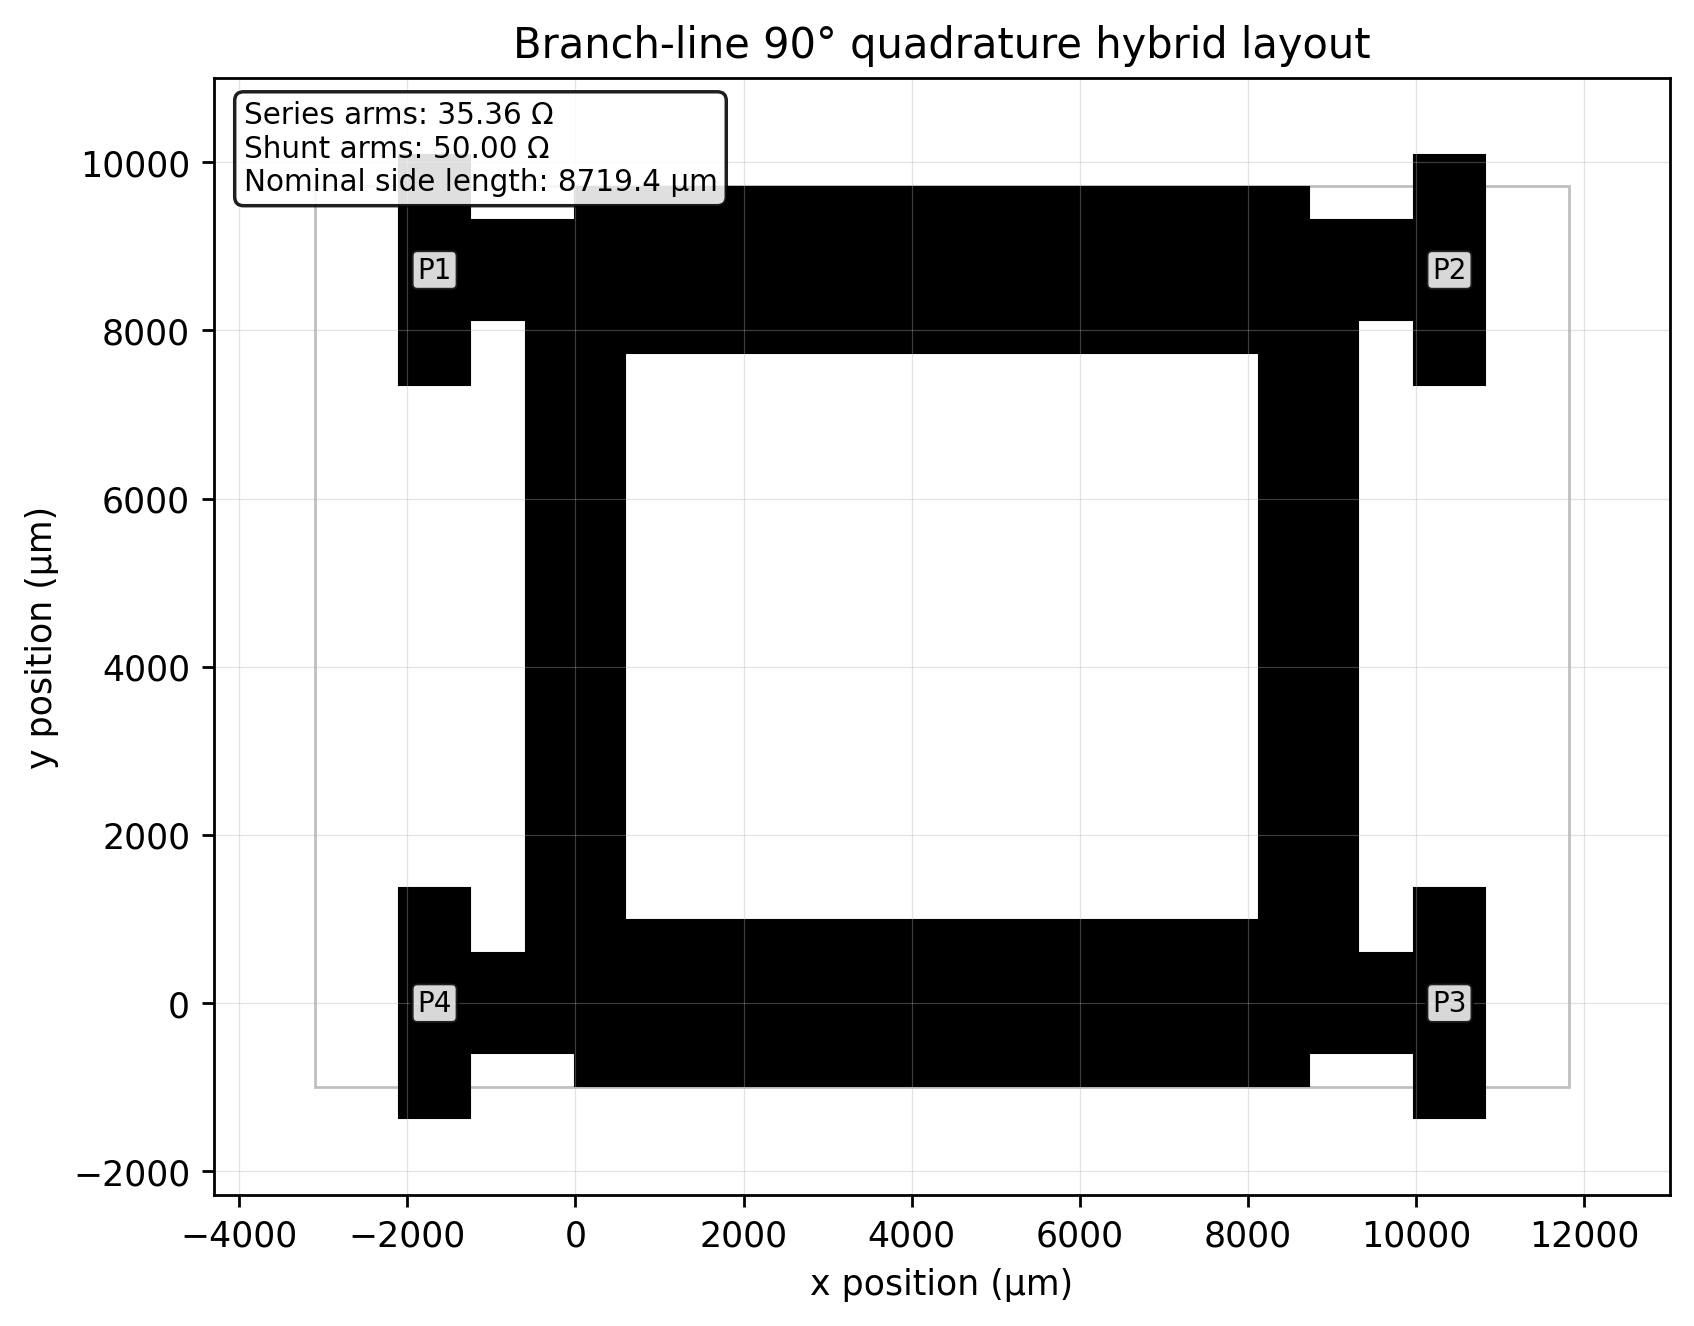

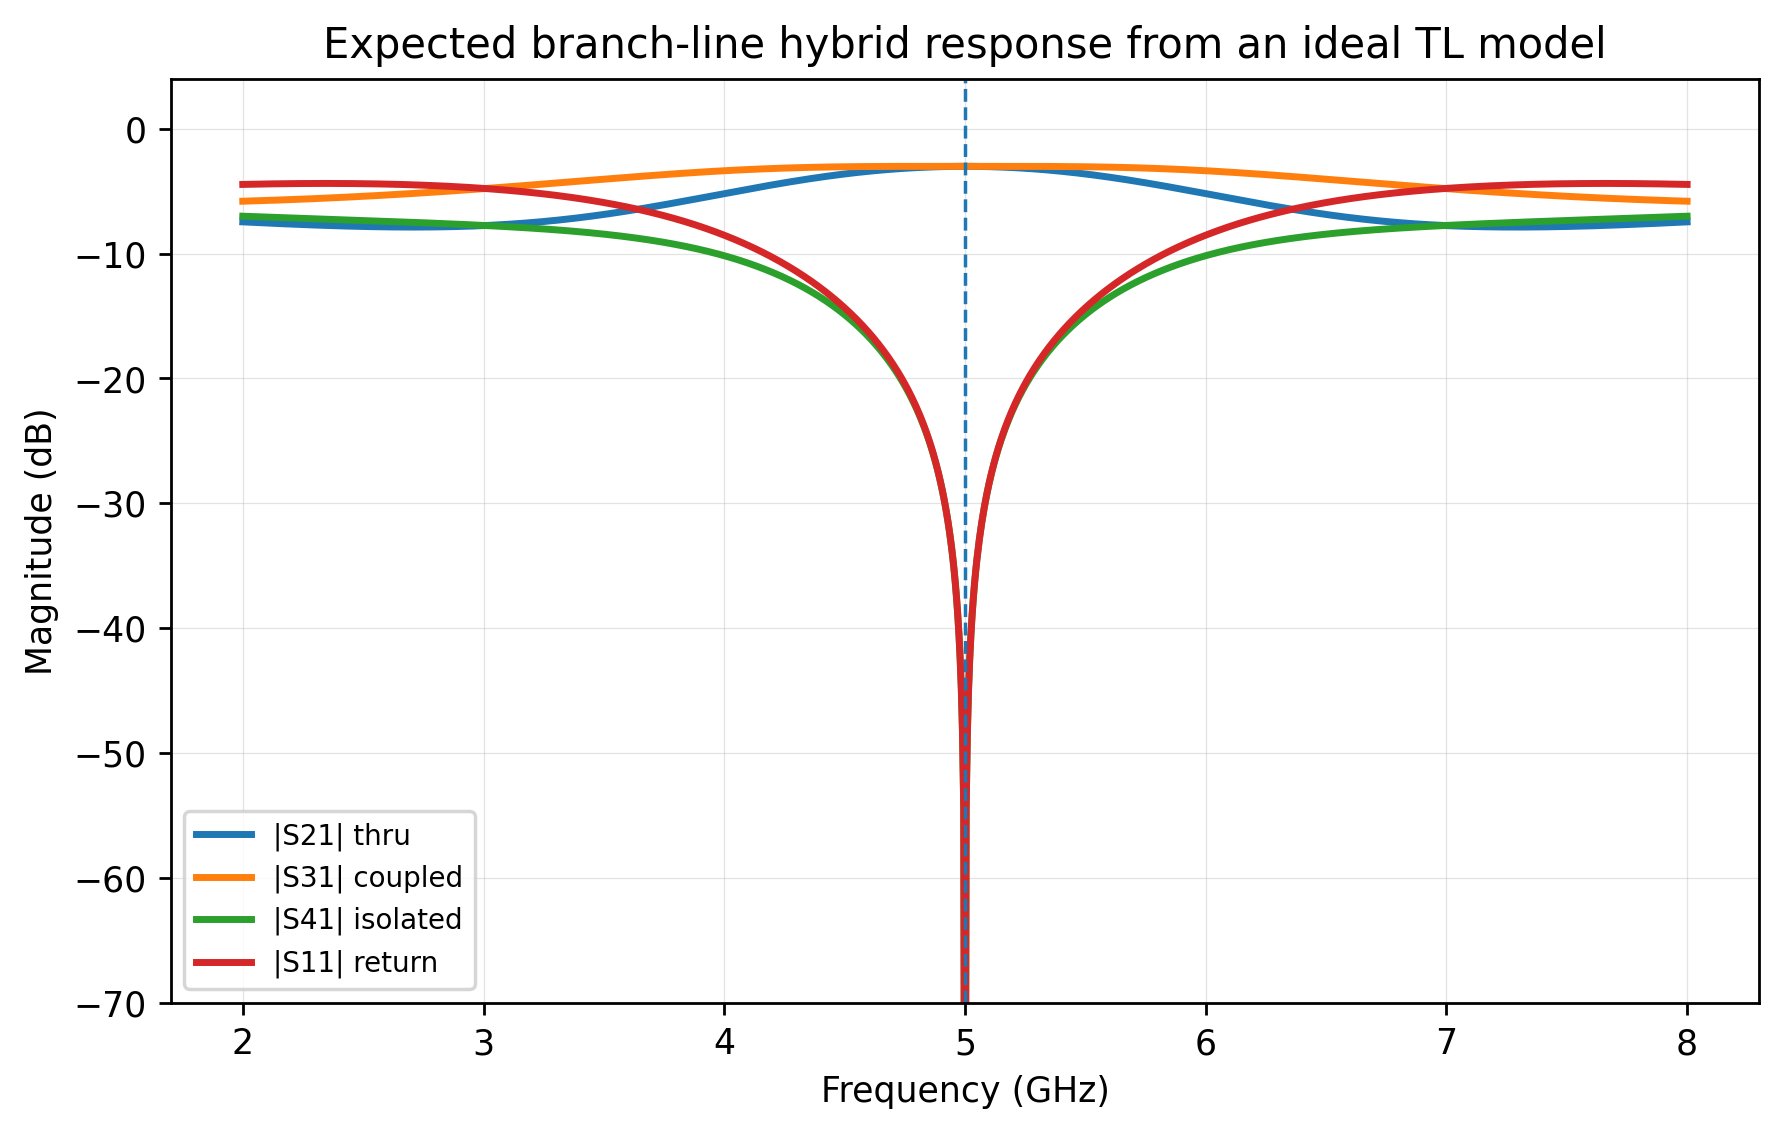

In [6]:
"""Generate a branch-line 90 degree quadrature hybrid coupler."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "branch_line_quadrature_hybrid"
SERIES_ARM_IMPEDANCE_OHM = Z0_OHM / np.sqrt(2.0)
SHUNT_ARM_IMPEDANCE_OHM = Z0_OHM
PORT_EXTENSION_UM = 1250.0
PORT_PAD_LENGTH_UM = 850.0
PORT_PAD_WIDTH_FACTOR = 2.3


# =============================================================================
# LAYOUT
# =============================================================================


def build_branchline_hybrid() -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build a square branch-line quadrature hybrid layout."""
    device = Device(COUPLER_NAME)
    series_width_um, _, series_length_um = quarter_wave_length_for_impedance(
        SERIES_ARM_IMPEDANCE_OHM,
    )
    shunt_width_um, _, shunt_length_um = quarter_wave_length_for_impedance(
        SHUNT_ARM_IMPEDANCE_OHM,
    )
    side_um = 0.5 * (series_length_um + shunt_length_um)

    add_rectangle(
        device,
        (-PORT_EXTENSION_UM - PORT_PAD_LENGTH_UM - 1000.0, -1000.0),
        (
            side_um
            + 2.0 * PORT_EXTENSION_UM
            + 2.0 * PORT_PAD_LENGTH_UM
            + 2000.0,
            side_um + 2000.0,
        ),
        BOUNDARY_LAYER,
    )

    add_centered_line(device, (0.0, side_um), (side_um, side_um), series_width_um, METAL_LAYER)
    add_centered_line(device, (0.0, 0.0), (side_um, 0.0), series_width_um, METAL_LAYER)
    add_centered_line(device, (0.0, 0.0), (0.0, side_um), shunt_width_um, METAL_LAYER)
    add_centered_line(device, (side_um, 0.0), (side_um, side_um), shunt_width_um, METAL_LAYER)

    port_points = [
        ((-PORT_EXTENSION_UM, side_um), (0.0, side_um), "P1"),
        ((side_um, side_um), (side_um + PORT_EXTENSION_UM, side_um), "P2"),
        ((side_um, 0.0), (side_um + PORT_EXTENSION_UM, 0.0), "P3"),
        ((-PORT_EXTENSION_UM, 0.0), (0.0, 0.0), "P4"),
    ]
    annotations = []

    for start_um, end_um, label in port_points:
        add_centered_line(device, start_um, end_um, feed_width_um, METAL_LAYER)
        center_x = start_um[0] - 0.5 * PORT_PAD_LENGTH_UM
        if start_um[0] > end_um[0]:
            center_x = start_um[0] + 0.5 * PORT_PAD_LENGTH_UM
        if start_um[0] < 0.0:
            pad_center = (start_um[0] - 0.5 * PORT_PAD_LENGTH_UM, start_um[1])
        else:
            pad_center = (end_um[0] + 0.5 * PORT_PAD_LENGTH_UM, end_um[1])
        add_port_pad(
            device,
            pad_center,
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )
        annotations.append((pad_center[0], pad_center[1], label))

    notes = (
        f"Series arms: {SERIES_ARM_IMPEDANCE_OHM:.2f} Ω\n"
        f"Shunt arms: {SHUNT_ARM_IMPEDANCE_OHM:.2f} Ω\n"
        f"Nominal side length: {side_um:.1f} µm"
    )
    return device, annotations, notes


branchline_device, branchline_annotations, branchline_notes = (
    build_branchline_hybrid()
)
export_and_report(branchline_device, COUPLER_NAME)

branchline_sections = [
    (0, 1, SERIES_ARM_IMPEDANCE_OHM, 0.5 * np.pi),
    (3, 2, SERIES_ARM_IMPEDANCE_OHM, 0.5 * np.pi),
    (0, 3, SHUNT_ARM_IMPEDANCE_OHM, 0.5 * np.pi),
    (1, 2, SHUNT_ARM_IMPEDANCE_OHM, 0.5 * np.pi),
]
branchline_s = network_response_from_tlines(
    frequency_ghz,
    branchline_sections,
    port_count=4,
)
branchline_traces = response_traces_from_s(
    branchline_s,
    {
        "|S21| thru": (1, 0),
        "|S31| coupled": (2, 0),
        "|S41| isolated": (3, 0),
        "|S11| return": (0, 0),
    },
)

render_layout(
    branchline_device,
    "Branch-line 90° quadrature hybrid layout",
    annotations=branchline_annotations,
    notes=branchline_notes,
)
render_response(
    frequency_ghz,
    branchline_traces,
    "Expected branch-line hybrid response from an ideal TL model",
)

Generated: rat_race_180_degree_hybrid
OASIS file: oas_coupler_layouts/rat_race_180_degree_hybrid.oas


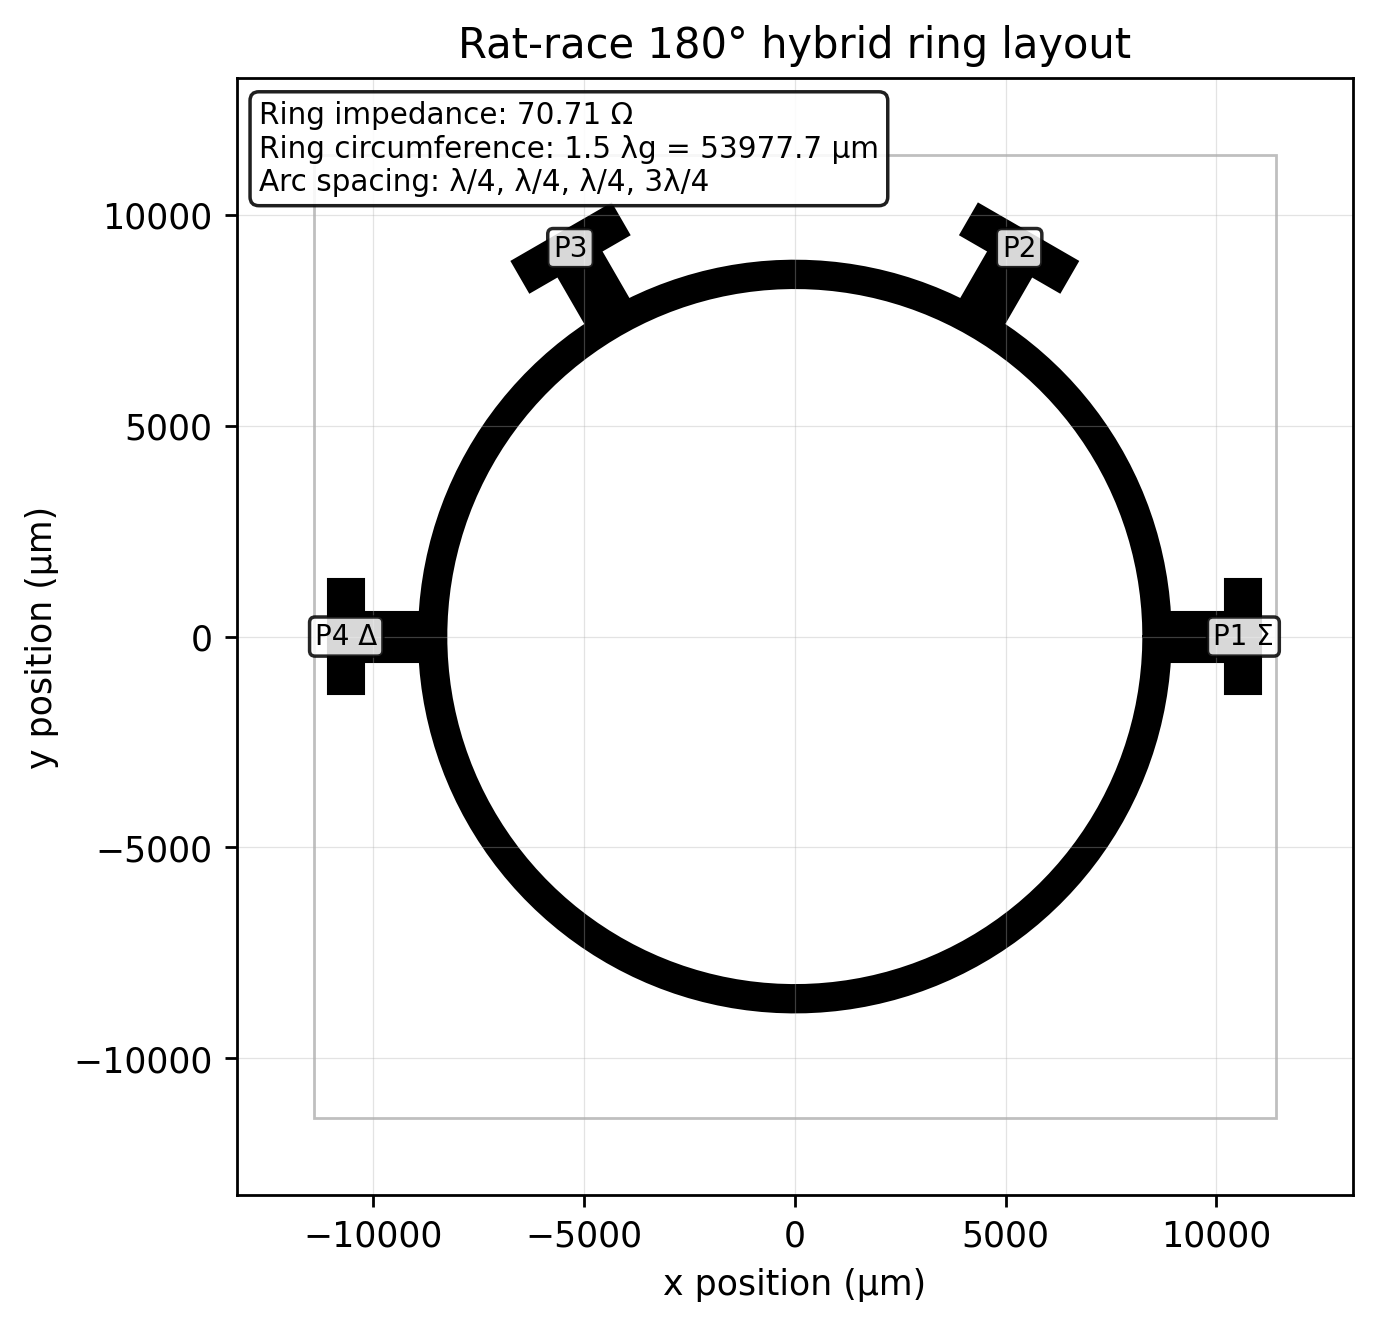

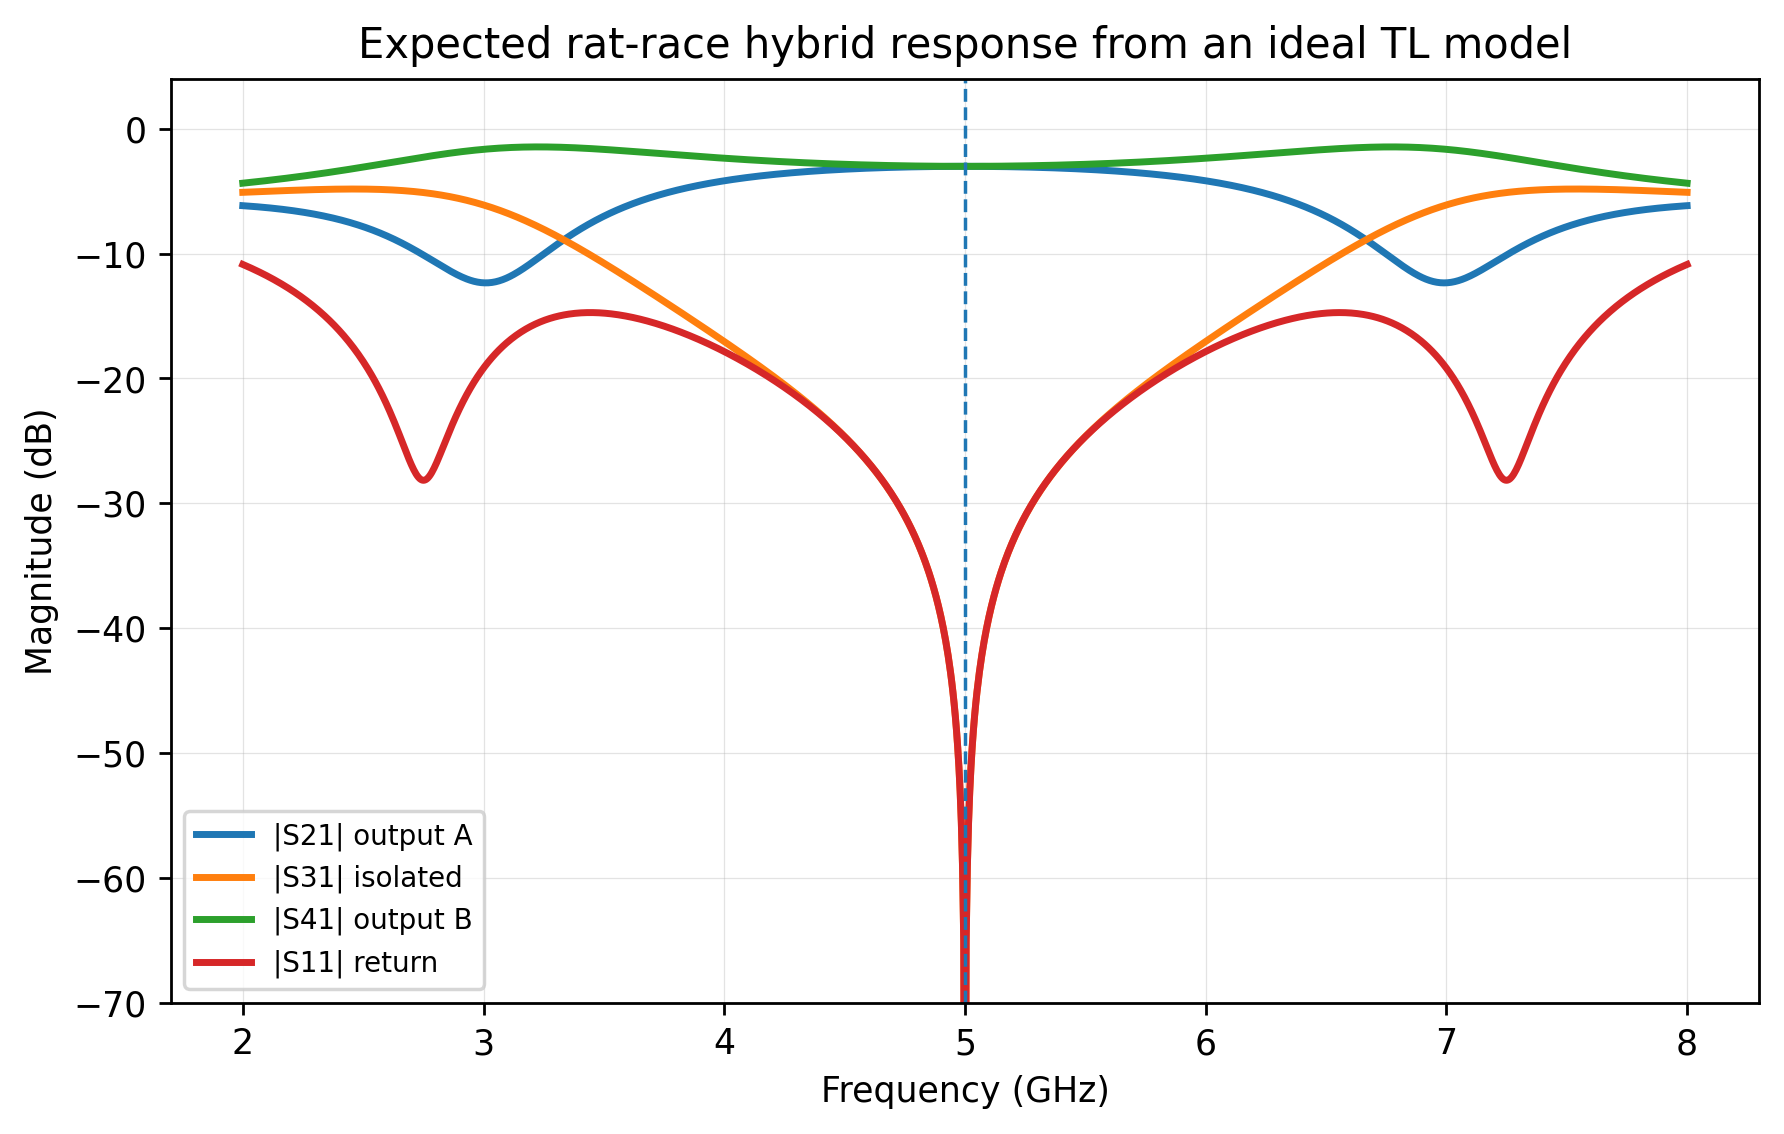

In [7]:
"""Generate a rat-race 180 degree hybrid ring coupler."""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "rat_race_180_degree_hybrid"
RING_IMPEDANCE_OHM = np.sqrt(2.0) * Z0_OHM
PORT_EXTENSION_UM = 1300.0
PORT_PAD_LENGTH_UM = 850.0
PORT_PAD_WIDTH_FACTOR = 2.3
RING_POINT_COUNT = 160


# =============================================================================
# LAYOUT
# =============================================================================


def build_rat_race_hybrid() -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build a rat-race hybrid ring layout with four radial feeds."""
    device = Device(COUPLER_NAME)
    ring_width_um, _, quarter_wave_um = quarter_wave_length_for_impedance(
        RING_IMPEDANCE_OHM,
    )
    ring_circumference_um = 6.0 * quarter_wave_um
    ring_radius_um = ring_circumference_um / (2.0 * np.pi)
    inner_radius_um = ring_radius_um - 0.5 * ring_width_um
    outer_radius_um = ring_radius_um + 0.5 * ring_width_um

    add_annular_sector(
        device,
        (0.0, 0.0),
        inner_radius_um,
        outer_radius_um,
        0.0,
        360.0,
        METAL_LAYER,
        point_count=RING_POINT_COUNT,
    )

    add_rectangle(
        device,
        (-outer_radius_um - 2500.0, -outer_radius_um - 2500.0),
        (2.0 * outer_radius_um + 5000.0, 2.0 * outer_radius_um + 5000.0),
        BOUNDARY_LAYER,
    )

    port_angles_deg = [0.0, 60.0, 120.0, 180.0]
    labels = ["P1 Σ", "P2", "P3", "P4 Δ"]
    annotations = []

    for angle_deg, label in zip(port_angles_deg, labels):
        angle_rad = np.deg2rad(angle_deg)
        direction = np.array([np.cos(angle_rad), np.sin(angle_rad)])
        start = outer_radius_um * direction
        end = (outer_radius_um + PORT_EXTENSION_UM) * direction
        pad_start = end
        pad_end = end + PORT_PAD_LENGTH_UM * direction

        add_centered_line(device, tuple(start), tuple(end), feed_width_um, METAL_LAYER)
        add_centered_line(
            device,
            tuple(pad_start),
            tuple(pad_end),
            feed_width_um * PORT_PAD_WIDTH_FACTOR,
            METAL_LAYER,
        )
        pad_center = 0.5 * (pad_start + pad_end)
        annotations.append((pad_center[0], pad_center[1], label))

    notes = (
        f"Ring impedance: {RING_IMPEDANCE_OHM:.2f} Ω\n"
        f"Ring circumference: 1.5 λg = {ring_circumference_um:.1f} µm\n"
        "Arc spacing: λ/4, λ/4, λ/4, 3λ/4"
    )
    return device, annotations, notes


rat_race_device, rat_race_annotations, rat_race_notes = build_rat_race_hybrid()
export_and_report(rat_race_device, COUPLER_NAME)

rat_race_sections = [
    (0, 1, RING_IMPEDANCE_OHM, 0.5 * np.pi),
    (1, 2, RING_IMPEDANCE_OHM, 0.5 * np.pi),
    (2, 3, RING_IMPEDANCE_OHM, 0.5 * np.pi),
    (3, 0, RING_IMPEDANCE_OHM, 1.5 * np.pi),
]
rat_race_s = network_response_from_tlines(
    frequency_ghz,
    rat_race_sections,
    port_count=4,
)
rat_race_traces = response_traces_from_s(
    rat_race_s,
    {
        "|S21| output A": (1, 0),
        "|S31| isolated": (2, 0),
        "|S41| output B": (3, 0),
        "|S11| return": (0, 0),
    },
)

render_layout(
    rat_race_device,
    "Rat-race 180° hybrid ring layout",
    annotations=rat_race_annotations,
    notes=rat_race_notes,
)
render_response(
    frequency_ghz,
    rat_race_traces,
    "Expected rat-race hybrid response from an ideal TL model",
)

Generated: lange_interdigitated_quadrature_coupler
OASIS file: oas_coupler_layouts/lange_interdigitated_quadrature_coupler.oas


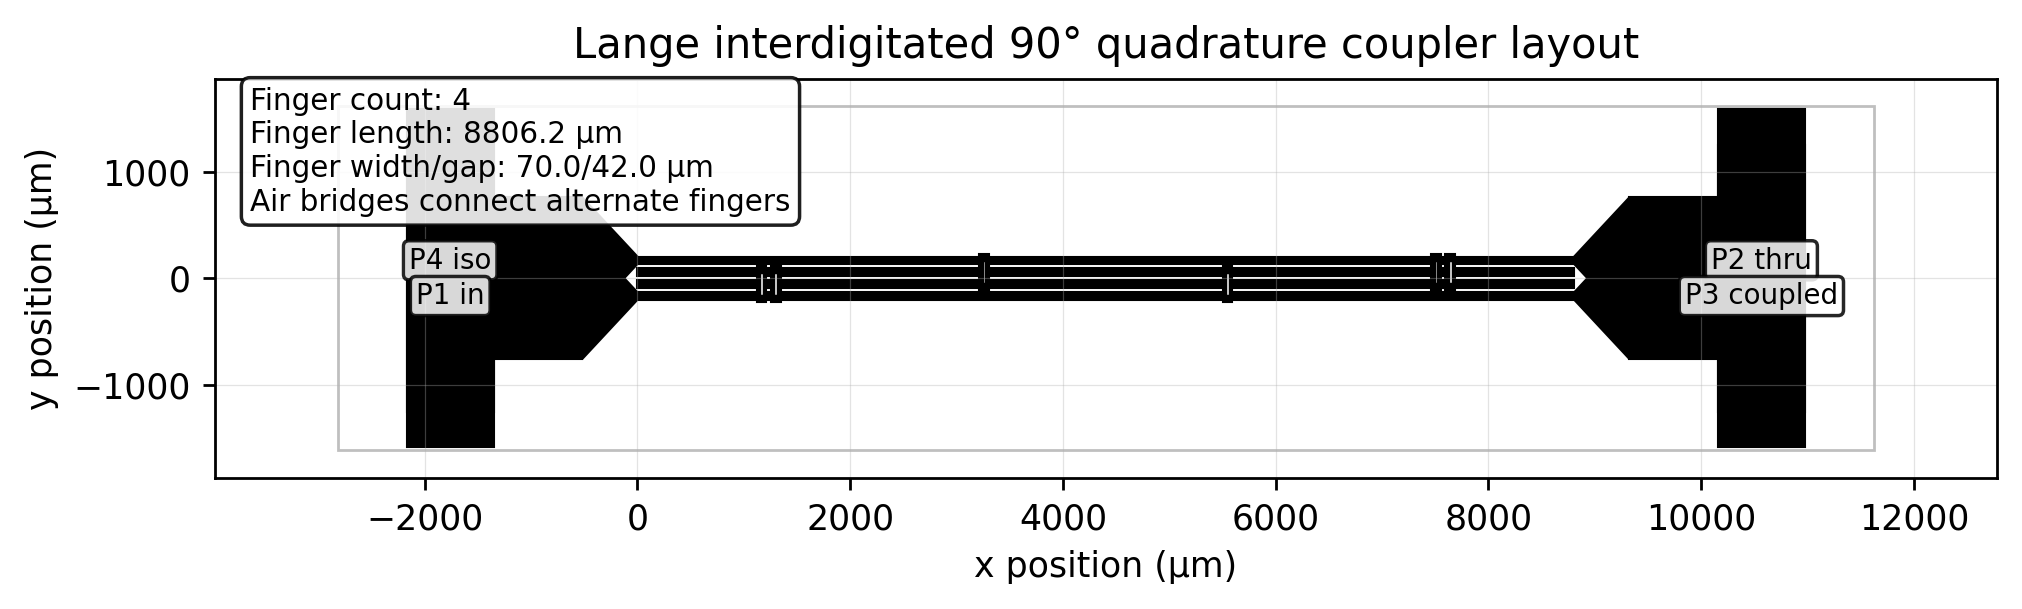

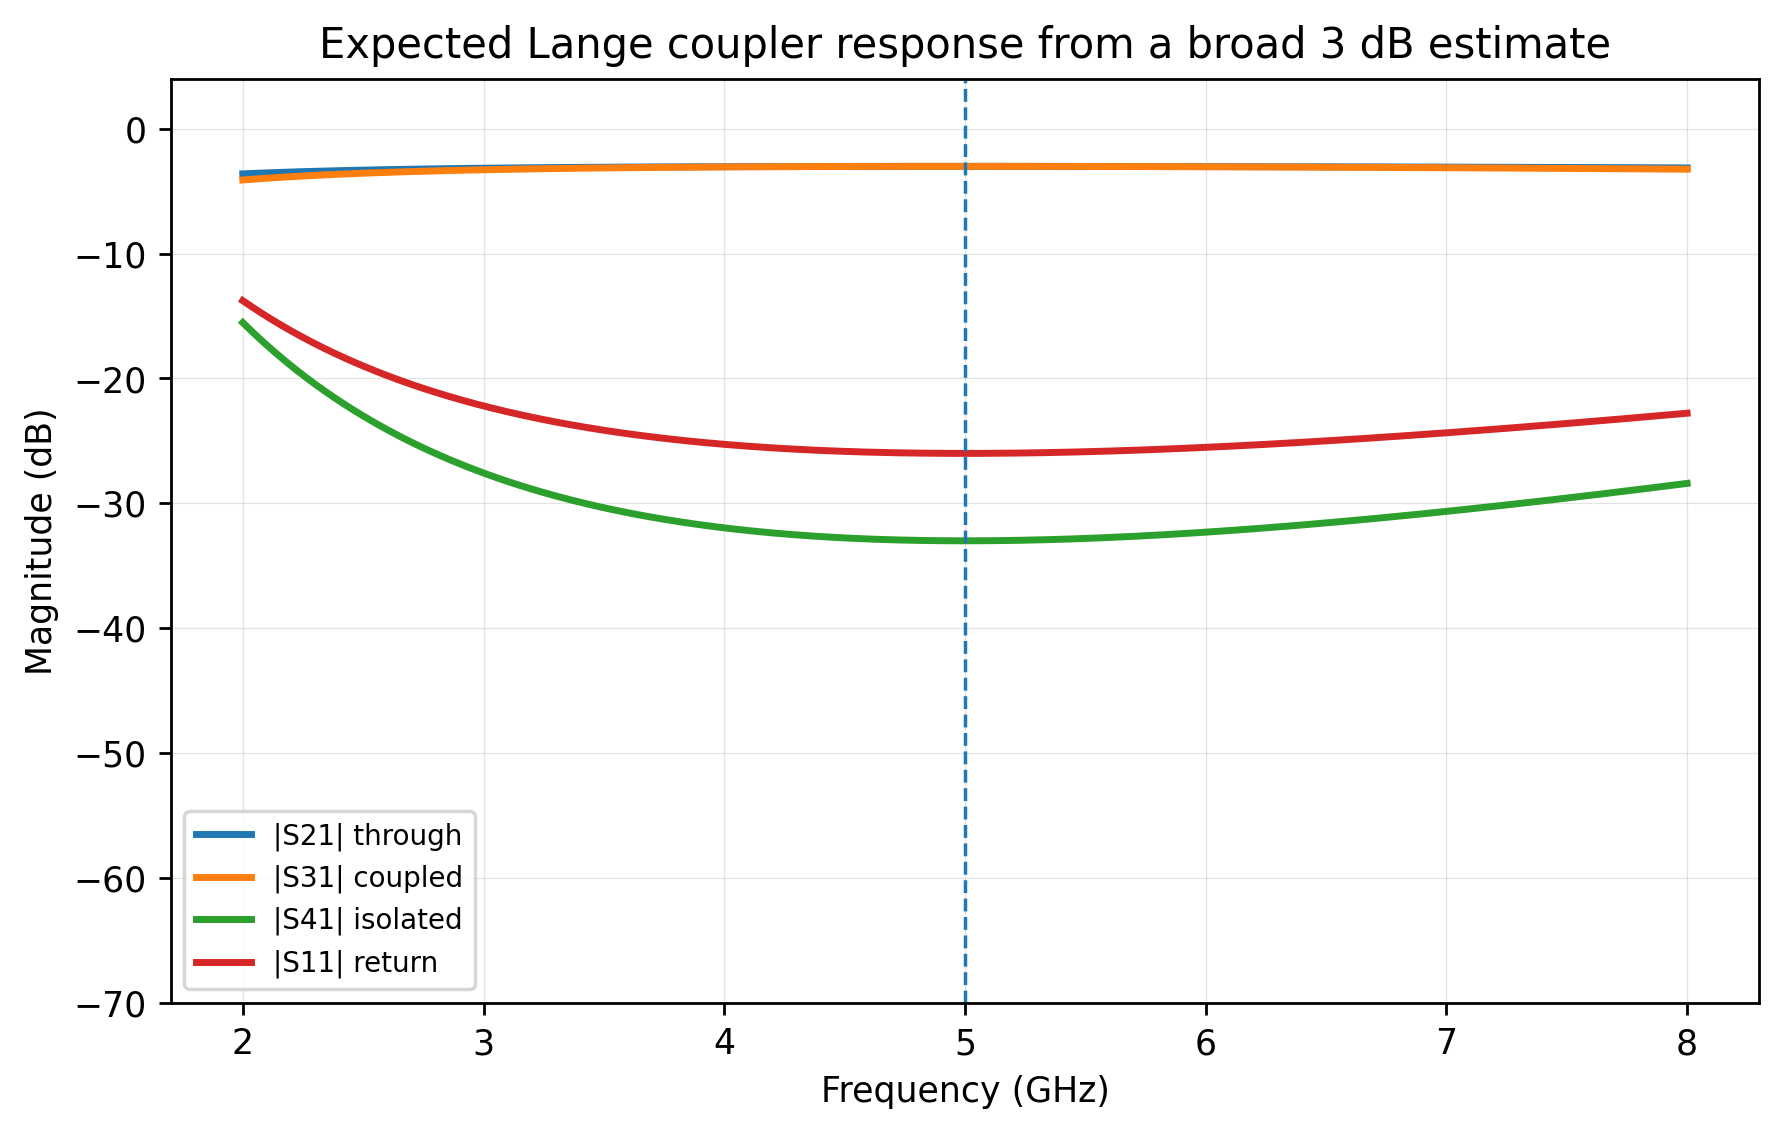

In [9]:
"""Generate a more topology-faithful Lange interdigitated quadrature coupler.

This replacement cell emphasizes the physical Lange geometry: narrow
interdigitated quarter-wave fingers, tapered 50-ohm port transitions, and
staggered air-bridge groups that interconnect alternate fingers.
"""

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "lange_interdigitated_quadrature_coupler"

FINGER_COUNT = 4
FINGER_WIDTH_UM = 70.0
FINGER_GAP_UM = 42.0

PORT_EXTENSION_UM = 1350.0
PORT_PAD_LENGTH_UM = 820.0
PORT_PAD_WIDTH_FACTOR = 2.4

TAPER_LENGTH_UM = 520.0
TAPER_SHOULDER_UM = 190.0

AIR_BRIDGE_WIDTH_UM = 44.0
AIR_BRIDGE_PAD_WIDTH_UM = 115.0
AIR_BRIDGE_PAD_LENGTH_UM = 90.0
AIR_BRIDGE_GROUP_SPACING_UM = 135.0
AIR_BRIDGE_END_OFFSET_FRACTION = 0.14

BOUNDARY_MARGIN_X_UM = 650.0
BOUNDARY_MARGIN_Y_UM = 1450.0


# =============================================================================
# GEOMETRY HELPERS
# =============================================================================


def add_tapered_strip(
    device: Device,
    start_xy_um: tuple[float, float],
    end_xy_um: tuple[float, float],
    start_width_um: float,
    end_width_um: float,
    layer: int,
) -> None:
    """Add a horizontal tapered strip polygon."""
    x_start_um, y_start_um = start_xy_um
    x_end_um, y_end_um = end_xy_um

    if abs(y_end_um - y_start_um) > 1.0e-9:
        raise ValueError("This helper expects a horizontal taper.")

    points = [
        (x_start_um, y_start_um - 0.5 * start_width_um),
        (x_start_um, y_start_um + 0.5 * start_width_um),
        (x_end_um, y_end_um + 0.5 * end_width_um),
        (x_end_um, y_end_um - 0.5 * end_width_um),
    ]
    device.add_polygon(points, layer=layer)


def add_bridge_landing_pair(
    device: Device,
    x_um: float,
    y_a_um: float,
    y_b_um: float,
) -> None:
    """Add metal landing pads and an air bridge between two fingers."""
    for y_um in (y_a_um, y_b_um):
        add_rectangle(
            device,
            (
                x_um - 0.5 * AIR_BRIDGE_PAD_LENGTH_UM,
                y_um - 0.5 * AIR_BRIDGE_PAD_WIDTH_UM,
            ),
            (AIR_BRIDGE_PAD_LENGTH_UM, AIR_BRIDGE_PAD_WIDTH_UM),
            METAL_LAYER,
        )

    add_centered_line(
        device,
        (x_um, y_a_um),
        (x_um, y_b_um),
        AIR_BRIDGE_WIDTH_UM,
        AIR_BRIDGE_LAYER,
    )


def add_bridge_group(
    device: Device,
    x_center_um: float,
    y_a_um: float,
    y_b_um: float,
    group_count: int = 2,
) -> None:
    """Add a small group of parallel bridge wires to reduce inductance."""
    offsets_um = (
        np.arange(group_count, dtype=np.float64)
        - 0.5 * (group_count - 1)
    ) * AIR_BRIDGE_GROUP_SPACING_UM

    for offset_um in offsets_um:
        add_bridge_landing_pair(device, x_center_um + offset_um, y_a_um, y_b_um)


# =============================================================================
# LAYOUT
# =============================================================================


def build_lange_coupler() -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build a four-finger Lange quadrature coupler layout."""
    device = Device(COUPLER_NAME)

    _, _, finger_length_um = quarter_wave_length_for_impedance(Z0_OHM)
    pitch_um = FINGER_WIDTH_UM + FINGER_GAP_UM

    y_positions_um = (
        np.arange(FINGER_COUNT, dtype=np.float64)
        - 0.5 * (FINGER_COUNT - 1)
    ) * pitch_um

    y_top_um = y_positions_um[-1]
    y_bottom_um = y_positions_um[0]

    coupled_region_x0_um = 0.0
    coupled_region_x1_um = finger_length_um

    boundary_x0_um = (
        -PORT_EXTENSION_UM
        - PORT_PAD_LENGTH_UM
        - BOUNDARY_MARGIN_X_UM
    )
    boundary_y0_um = y_bottom_um - BOUNDARY_MARGIN_Y_UM
    boundary_width_um = (
        finger_length_um
        + 2.0 * PORT_EXTENSION_UM
        + 2.0 * PORT_PAD_LENGTH_UM
        + 2.0 * BOUNDARY_MARGIN_X_UM
    )
    boundary_height_um = (
        y_top_um
        - y_bottom_um
        + 2.0 * BOUNDARY_MARGIN_Y_UM
    )

    add_rectangle(
        device,
        (boundary_x0_um, boundary_y0_um),
        (boundary_width_um, boundary_height_um),
        BOUNDARY_LAYER,
    )

    for y_um in y_positions_um:
        add_centered_line(
            device,
            (coupled_region_x0_um, y_um),
            (coupled_region_x1_um, y_um),
            FINGER_WIDTH_UM,
            METAL_LAYER,
        )

    left_port_rows = {
        "P4 iso": 3,
        "P1 in": 0,
    }
    right_port_rows = {
        "P2 thru": 3,
        "P3 coupled": 0,
    }

    annotations = []

    for label, row_index in left_port_rows.items():
        y_um = y_positions_um[row_index]
        pad_center_x_um = (
            -PORT_EXTENSION_UM
            - 0.5 * PORT_PAD_LENGTH_UM
        )

        add_centered_line(
            device,
            (-PORT_EXTENSION_UM, y_um),
            (-TAPER_LENGTH_UM, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_tapered_strip(
            device,
            (-TAPER_LENGTH_UM, y_um),
            (0.0, y_um),
            feed_width_um,
            FINGER_WIDTH_UM,
            METAL_LAYER,
        )
        add_port_pad(
            device,
            (pad_center_x_um, y_um),
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )

        annotations.append((pad_center_x_um, y_um, label))

    for label, row_index in right_port_rows.items():
        y_um = y_positions_um[row_index]
        pad_center_x_um = (
            finger_length_um
            + PORT_EXTENSION_UM
            + 0.5 * PORT_PAD_LENGTH_UM
        )

        add_tapered_strip(
            device,
            (finger_length_um, y_um),
            (finger_length_um + TAPER_LENGTH_UM, y_um),
            FINGER_WIDTH_UM,
            feed_width_um,
            METAL_LAYER,
        )
        add_centered_line(
            device,
            (finger_length_um + TAPER_LENGTH_UM, y_um),
            (finger_length_um + PORT_EXTENSION_UM, y_um),
            feed_width_um,
            METAL_LAYER,
        )
        add_port_pad(
            device,
            (pad_center_x_um, y_um),
            (PORT_PAD_LENGTH_UM, feed_width_um * PORT_PAD_WIDTH_FACTOR),
        )

        annotations.append((pad_center_x_um, y_um, label))

    x_left_bridge_um = AIR_BRIDGE_END_OFFSET_FRACTION * finger_length_um
    x_right_bridge_um = (
        1.0 - AIR_BRIDGE_END_OFFSET_FRACTION
    ) * finger_length_um

    add_bridge_group(
        device,
        x_left_bridge_um,
        y_positions_um[0],
        y_positions_um[2],
        group_count=2,
    )
    add_bridge_group(
        device,
        x_right_bridge_um,
        y_positions_um[1],
        y_positions_um[3],
        group_count=2,
    )

    add_bridge_group(
        device,
        x_left_bridge_um + 0.23 * finger_length_um,
        y_positions_um[1],
        y_positions_um[3],
        group_count=1,
    )
    add_bridge_group(
        device,
        x_right_bridge_um - 0.23 * finger_length_um,
        y_positions_um[0],
        y_positions_um[2],
        group_count=1,
    )

    notes = (
        f"Finger count: {FINGER_COUNT}\n"
        f"Finger length: {finger_length_um:.1f} µm\n"
        f"Finger width/gap: {FINGER_WIDTH_UM:.1f}/{FINGER_GAP_UM:.1f} µm\n"
        "Air bridges connect alternate fingers"
    )

    return device, annotations, notes


lange_device, lange_annotations, lange_notes = build_lange_coupler()
export_and_report(lange_device, COUPLER_NAME)

lange_traces = lange_response(frequency_ghz)

render_layout(
    lange_device,
    "Lange interdigitated 90° quadrature coupler layout",
    annotations=lange_annotations,
    notes=lange_notes,
)

render_response(
    frequency_ghz,
    lange_traces,
    "Expected Lange coupler response from a broad 3 dB estimate",
)

Generated: lange_bowtie_launch_quadrature_coupler
OASIS file: oas_coupler_layouts/lange_bowtie_launch_quadrature_coupler.oas
Bowtie-launch Lange coupler variant generated.
OASIS path: oas_coupler_layouts/lange_bowtie_launch_quadrature_coupler.oas


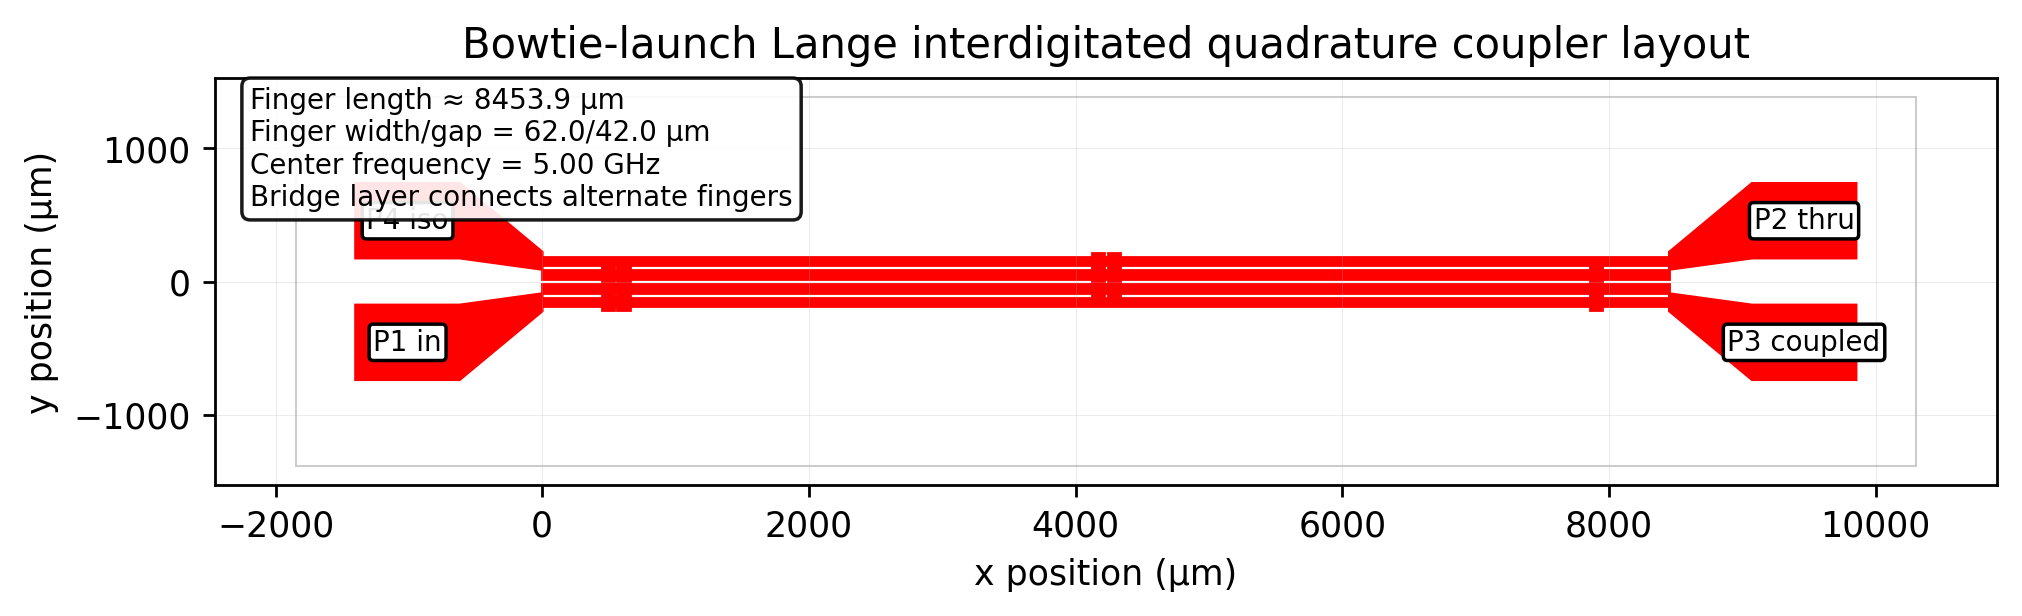

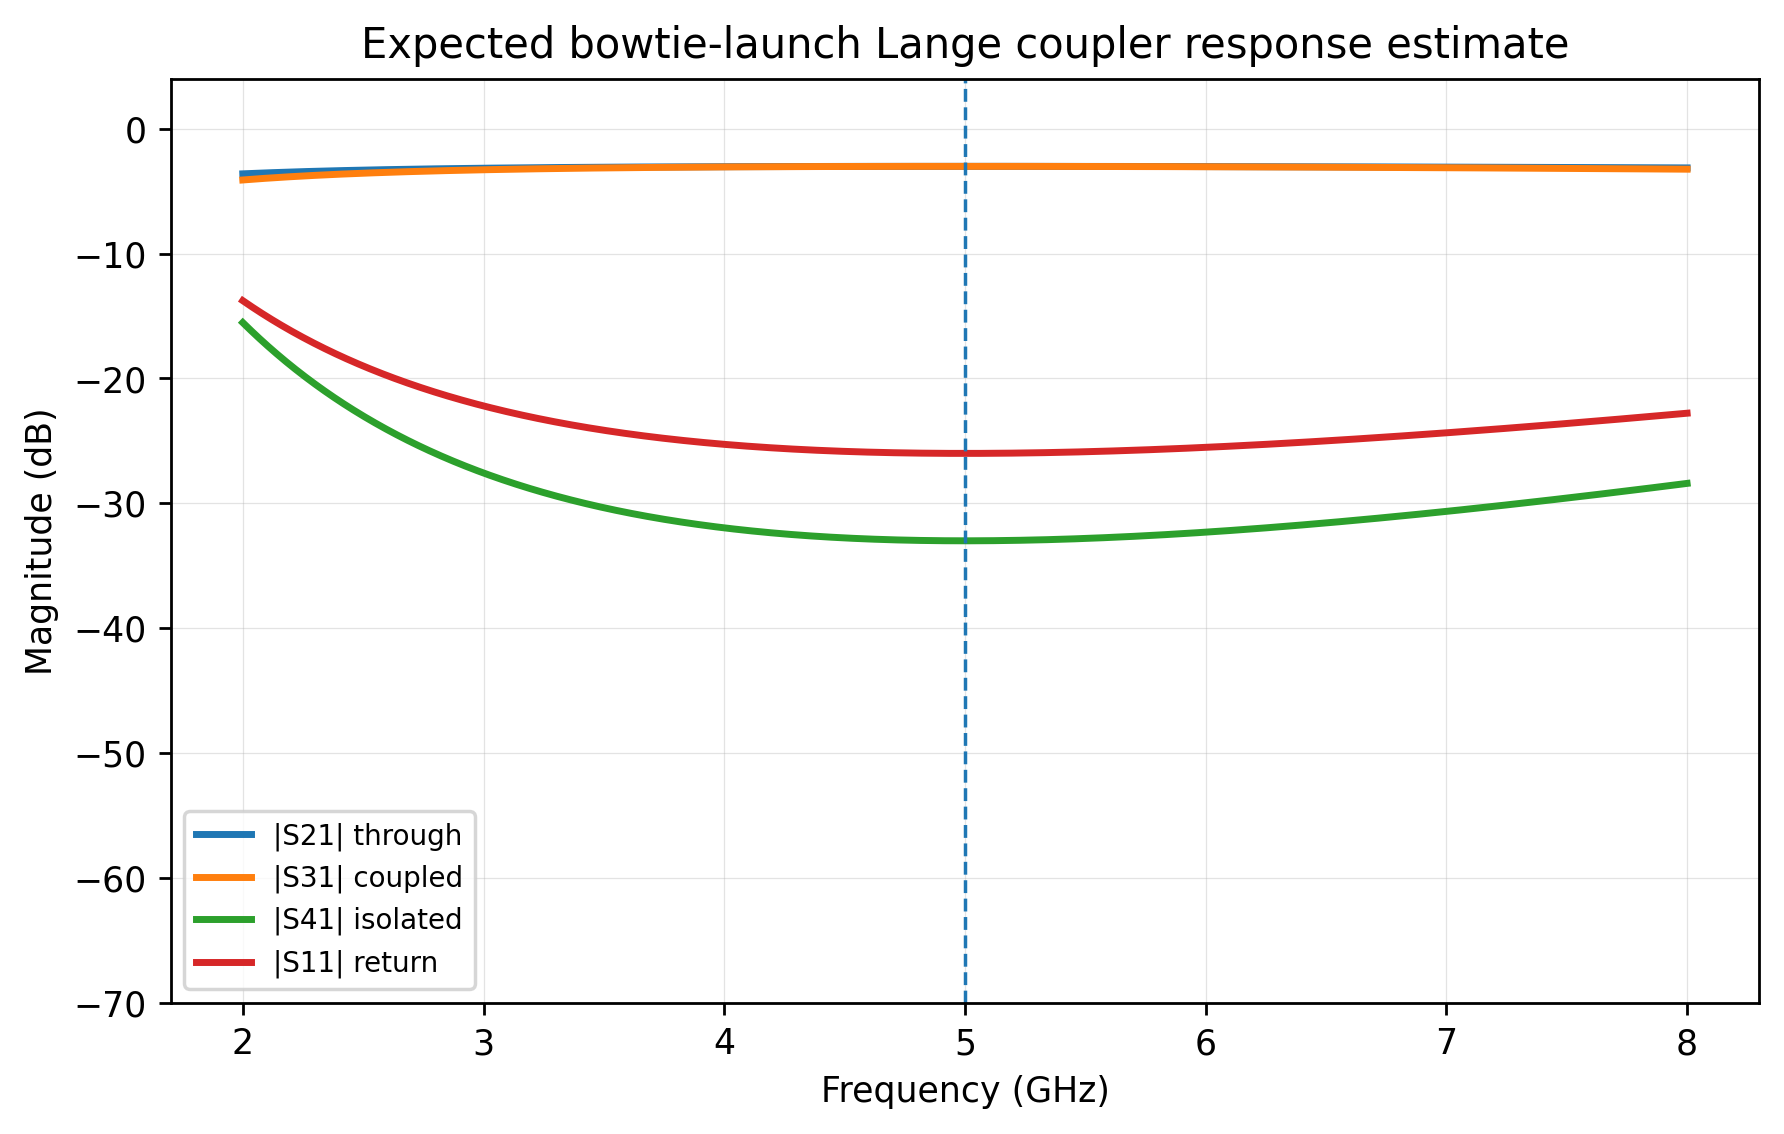

In [10]:
"""Generate a bowtie-launch Lange quadrature coupler variant.

This cell creates a Lange-style interdigitated coupler resembling a
wide-launch mask layout with tapered bowtie ports, four narrow coupled
fingers, and air-bridge columns that connect alternate fingers.
"""

# =============================================================================
# IMPORTS AND FALLBACKS
# =============================================================================

from pathlib import Path

import gdstk
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon as MplPolygon
from phidl import Device

# =============================================================================
# CONTROL KNOBS
# =============================================================================

COUPLER_NAME = "lange_bowtie_launch_quadrature_coupler"

Z0_OHM = globals().get("Z0_OHM", 50.0)
CENTER_FREQUENCY_GHZ = globals().get("CENTER_FREQUENCY_GHZ", 5.0)
EPSILON_R = globals().get("EPSILON_R", 9.9)
SUBSTRATE_HEIGHT_UM = globals().get("SUBSTRATE_HEIGHT_UM", 508.0)

METAL_LAYER = globals().get("METAL_LAYER", 1)
AIR_BRIDGE_LAYER = globals().get("AIR_BRIDGE_LAYER", 3)
BOUNDARY_LAYER = globals().get("BOUNDARY_LAYER", 10)

FINGER_COUNT = 4
FINGER_WIDTH_UM = 62.0
FINGER_GAP_UM = 42.0
FINGER_LENGTH_SCALE = 0.96

LAUNCH_PAD_LENGTH_UM = 780.0
LAUNCH_PAD_HEIGHT_UM = 560.0
BOWTIE_TAPER_LENGTH_UM = 620.0
BOWTIE_NECK_WIDTH_UM = 130.0
LAUNCH_VERTICAL_OFFSET_UM = 300.0

AIR_BRIDGE_WIDTH_UM = 42.0
AIR_BRIDGE_LANDING_LENGTH_UM = 92.0
AIR_BRIDGE_LANDING_WIDTH_UM = 110.0
AIR_BRIDGE_GROUP_SPACING_UM = 118.0

LEFT_BRIDGE_X_FRACTION = 0.065
CENTER_BRIDGE_X_FRACTION = 0.500
RIGHT_BRIDGE_X_FRACTION = 0.935

BOUNDARY_MARGIN_X_UM = 450.0
BOUNDARY_MARGIN_Y_UM = 650.0

OASIS_DIRECTORY = Path("oas_coupler_layouts")
RESPONSE_FREQUENCY_MIN_GHZ = 0.45 * CENTER_FREQUENCY_GHZ
RESPONSE_FREQUENCY_MAX_GHZ = 1.55 * CENTER_FREQUENCY_GHZ
RESPONSE_FREQUENCY_POINTS = 1201


# =============================================================================
# BASIC GEOMETRY HELPERS
# =============================================================================

def get_quarter_wave_length_um() -> float:
    """Return a quarter-wave physical length estimate in micrometers."""
    if "quarter_wave_length_for_impedance" in globals():
        _, _, length_um = quarter_wave_length_for_impedance(Z0_OHM)
        return FINGER_LENGTH_SCALE * float(length_um)

    epsilon_eff = 0.5 * (EPSILON_R + 1.0)
    speed_of_light_um_per_s = 2.99792458e14
    frequency_hz = CENTER_FREQUENCY_GHZ * 1.0e9
    wavelength_um = speed_of_light_um_per_s / (
        frequency_hz * np.sqrt(epsilon_eff)
    )
    return FINGER_LENGTH_SCALE * 0.25 * wavelength_um


def add_lange_rectangle(
    device: Device,
    origin_um: tuple[float, float],
    size_um: tuple[float, float],
    layer: int,
) -> None:
    """Add an axis-aligned rectangle to a PHIDL device."""
    x_um, y_um = origin_um
    width_um, height_um = size_um

    points = [
        (x_um, y_um),
        (x_um + width_um, y_um),
        (x_um + width_um, y_um + height_um),
        (x_um, y_um + height_um),
    ]
    device.add_polygon(points, layer=layer)


def add_lange_centered_line(
    device: Device,
    start_um: tuple[float, float],
    end_um: tuple[float, float],
    width_um: float,
    layer: int,
) -> None:
    """Add a horizontal or vertical centered rectangular line."""
    x0_um, y0_um = start_um
    x1_um, y1_um = end_um

    if abs(y1_um - y0_um) <= 1.0e-9:
        x_min_um = min(x0_um, x1_um)
        length_um = abs(x1_um - x0_um)
        add_lange_rectangle(
            device,
            (x_min_um, y0_um - 0.5 * width_um),
            (length_um, width_um),
            layer,
        )
        return

    if abs(x1_um - x0_um) <= 1.0e-9:
        y_min_um = min(y0_um, y1_um)
        length_um = abs(y1_um - y0_um)
        add_lange_rectangle(
            device,
            (x0_um - 0.5 * width_um, y_min_um),
            (width_um, length_um),
            layer,
        )
        return

    raise ValueError("Only horizontal and vertical lines are supported.")


def add_bowtie_launch(
    device: Device,
    side: str,
    pad_center_y_um: float,
    finger_y_um: float,
    finger_x_um: float,
) -> tuple[float, float]:
    """Add a wide bowtie transition between a port pad and a finger."""
    if side == "left":
        pad_outer_x_um = -BOWTIE_TAPER_LENGTH_UM - LAUNCH_PAD_LENGTH_UM
        pad_inner_x_um = -BOWTIE_TAPER_LENGTH_UM
        points = [
            (pad_outer_x_um, pad_center_y_um - 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (pad_outer_x_um, pad_center_y_um + 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (pad_inner_x_um, pad_center_y_um + 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (finger_x_um, finger_y_um + 0.5 * BOWTIE_NECK_WIDTH_UM),
            (finger_x_um, finger_y_um - 0.5 * BOWTIE_NECK_WIDTH_UM),
            (pad_inner_x_um, pad_center_y_um - 0.5 * LAUNCH_PAD_HEIGHT_UM),
        ]
        annotation_x_um = pad_outer_x_um + 0.5 * LAUNCH_PAD_LENGTH_UM

    elif side == "right":
        pad_inner_x_um = finger_x_um + BOWTIE_TAPER_LENGTH_UM
        pad_outer_x_um = pad_inner_x_um + LAUNCH_PAD_LENGTH_UM
        points = [
            (finger_x_um, finger_y_um - 0.5 * BOWTIE_NECK_WIDTH_UM),
            (finger_x_um, finger_y_um + 0.5 * BOWTIE_NECK_WIDTH_UM),
            (pad_inner_x_um, pad_center_y_um + 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (pad_outer_x_um, pad_center_y_um + 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (pad_outer_x_um, pad_center_y_um - 0.5 * LAUNCH_PAD_HEIGHT_UM),
            (pad_inner_x_um, pad_center_y_um - 0.5 * LAUNCH_PAD_HEIGHT_UM),
        ]
        annotation_x_um = pad_outer_x_um - 0.5 * LAUNCH_PAD_LENGTH_UM

    else:
        raise ValueError("side must be 'left' or 'right'.")

    device.add_polygon(points, layer=METAL_LAYER)
    return annotation_x_um, pad_center_y_um


def add_air_bridge(
    device: Device,
    x_um: float,
    y_a_um: float,
    y_b_um: float,
) -> None:
    """Add a vertical air bridge with metal landing pads."""
    for y_um in (y_a_um, y_b_um):
        add_lange_rectangle(
            device,
            (
                x_um - 0.5 * AIR_BRIDGE_LANDING_LENGTH_UM,
                y_um - 0.5 * AIR_BRIDGE_LANDING_WIDTH_UM,
            ),
            (AIR_BRIDGE_LANDING_LENGTH_UM, AIR_BRIDGE_LANDING_WIDTH_UM),
            METAL_LAYER,
        )

    add_lange_centered_line(
        device,
        (x_um, y_a_um),
        (x_um, y_b_um),
        AIR_BRIDGE_WIDTH_UM,
        AIR_BRIDGE_LAYER,
    )


def add_air_bridge_group(
    device: Device,
    x_center_um: float,
    y_a_um: float,
    y_b_um: float,
    bridge_count: int,
) -> None:
    """Add one or more closely spaced air bridges."""
    offsets_um = (
        np.arange(bridge_count, dtype=np.float64)
        - 0.5 * (bridge_count - 1)
    ) * AIR_BRIDGE_GROUP_SPACING_UM

    for offset_um in offsets_um:
        add_air_bridge(device, x_center_um + offset_um, y_a_um, y_b_um)


# =============================================================================
# EXPORT AND RESPONSE HELPERS
# =============================================================================

def export_lange_variant_device(device: Device, cell_name: str) -> Path:
    """Export the PHIDL device as an OASIS file."""
    if "export_and_report" in globals():
        export_and_report(device, cell_name)
        return OASIS_DIRECTORY / f"{cell_name}.oas"

    library = gdstk.Library(unit=1.0e-6, precision=1.0e-9)
    cell = library.new_cell(cell_name.upper()[:64])

    for layer_spec, polygons in device.get_polygons(by_spec=True).items():
        if isinstance(layer_spec, tuple):
            layer, data_type = layer_spec
        else:
            layer, data_type = int(layer_spec), 0

        for polygon_points in polygons:
            cell.add(
                gdstk.Polygon(
                    polygon_points,
                    layer=int(layer),
                    datatype=int(data_type),
                )
            )

    OASIS_DIRECTORY.mkdir(parents=True, exist_ok=True)
    file_path = OASIS_DIRECTORY / f"{cell_name}.oas"
    library.write_oas(str(file_path))
    print(f"OASIS file written to {file_path}")
    return file_path


def estimate_lange_response(
    frequency_ghz: np.ndarray,
) -> dict[str, np.ndarray]:
    """Return a broad first-pass Lange coupler response estimate."""
    if "lange_response" in globals():
        return lange_response(frequency_ghz)

    normalized_offset = (
        frequency_ghz - CENTER_FREQUENCY_GHZ
    ) / CENTER_FREQUENCY_GHZ

    thru_db = -3.05 - 0.65 * normalized_offset**2
    coupled_db = -3.15 - 0.85 * normalized_offset**2
    isolation_db = -32.0 + 11.0 * np.abs(normalized_offset)
    return_loss_db = -23.0 + 8.0 * np.abs(normalized_offset)

    return {
        "|S21| thru estimate (dB)": thru_db,
        "|S31| coupled estimate (dB)": coupled_db,
        "|S41| isolation estimate (dB)": isolation_db,
        "|S11| return estimate (dB)": return_loss_db,
    }


def render_lange_variant_layout(
    device: Device,
    title: str,
    annotations: list[tuple[float, float, str]],
    notes: str,
) -> None:
    """Render the bowtie Lange layout with a red mask-style preview."""
    figure, axis = plt.subplots(figsize=(9.2, 4.5), dpi=250)

    layer_styles = {
        METAL_LAYER: {
            "facecolor": "red",
            "edgecolor": "red",
            "alpha": 1.0,
            "linewidth": 0.8,
        },
        AIR_BRIDGE_LAYER: {
            "facecolor": "red",
            "edgecolor": "red",
            "alpha": 0.78,
            "linewidth": 0.8,
        },
        BOUNDARY_LAYER: {
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.20,
            "linewidth": 0.6,
        },
    }

    for layer_spec, polygons in device.get_polygons(by_spec=True).items():
        if isinstance(layer_spec, tuple):
            layer = int(layer_spec[0])
        else:
            layer = int(layer_spec)

        style = layer_styles.get(
            layer,
            {
                "facecolor": "none",
                "edgecolor": "black",
                "alpha": 1.0,
                "linewidth": 0.6,
            },
        )

        for points in polygons:
            axis.add_patch(MplPolygon(points, closed=True, **style))

    for x_um, y_um, label in annotations:
        axis.text(
            x_um,
            y_um,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            bbox={"boxstyle": "round,pad=0.15", "facecolor": "white"},
        )

    axis.text(
        0.02,
        0.98,
        notes,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
    )

    axis.autoscale_view()
    axis.set_aspect("equal", adjustable="box")
    axis.set_title(title)
    axis.set_xlabel("x position (µm)")
    axis.set_ylabel("y position (µm)")
    axis.grid(True, linewidth=0.3, alpha=0.25)
    plt.show()


def render_lange_variant_response(
    frequency_ghz: np.ndarray,
    traces: dict[str, np.ndarray],
    title: str,
) -> None:
    """Render the expected RF response for the Lange variant."""
    if "render_response" in globals():
        render_response(frequency_ghz, traces, title)
        return

    figure, axis = plt.subplots(figsize=(8.0, 4.8), dpi=250)

    for label, values_db in traces.items():
        axis.plot(frequency_ghz, values_db, linewidth=2.0, label=label)

    axis.axvline(CENTER_FREQUENCY_GHZ, linestyle="--", linewidth=1.0)
    axis.set_xlabel("Frequency (GHz)")
    axis.set_ylabel("Magnitude estimate (dB)")
    axis.set_title(title)
    axis.set_ylim(-45.0, 1.0)
    axis.grid(True, linewidth=0.35, alpha=0.35)
    axis.legend(fontsize=8)
    plt.show()


# =============================================================================
# LAYOUT CONSTRUCTION
# =============================================================================

def build_bowtie_lange_coupler(
) -> tuple[Device, list[tuple[float, float, str]], str]:
    """Build the bowtie-launch Lange coupler variant."""
    device = Device(COUPLER_NAME)

    finger_length_um = get_quarter_wave_length_um()
    pitch_um = FINGER_WIDTH_UM + FINGER_GAP_UM

    y_positions_um = (
        np.arange(FINGER_COUNT, dtype=np.float64)
        - 0.5 * (FINGER_COUNT - 1)
    ) * pitch_um

    y_bottom_um = y_positions_um[0]
    y_top_um = y_positions_um[-1]
    lower_launch_y_um = y_bottom_um - LAUNCH_VERTICAL_OFFSET_UM
    upper_launch_y_um = y_top_um + LAUNCH_VERTICAL_OFFSET_UM

    x_left_um = -BOWTIE_TAPER_LENGTH_UM - LAUNCH_PAD_LENGTH_UM
    x_right_um = finger_length_um + BOWTIE_TAPER_LENGTH_UM + LAUNCH_PAD_LENGTH_UM

    add_lange_rectangle(
        device,
        (
            x_left_um - BOUNDARY_MARGIN_X_UM,
            lower_launch_y_um
            - 0.5 * LAUNCH_PAD_HEIGHT_UM
            - BOUNDARY_MARGIN_Y_UM,
        ),
        (
            x_right_um
            - x_left_um
            + 2.0 * BOUNDARY_MARGIN_X_UM,
            upper_launch_y_um
            - lower_launch_y_um
            + LAUNCH_PAD_HEIGHT_UM
            + 2.0 * BOUNDARY_MARGIN_Y_UM,
        ),
        BOUNDARY_LAYER,
    )

    for y_um in y_positions_um:
        add_lange_centered_line(
            device,
            (0.0, y_um),
            (finger_length_um, y_um),
            FINGER_WIDTH_UM,
            METAL_LAYER,
        )

    annotations = []

    annotations.append(
        (*add_bowtie_launch(device, "left", upper_launch_y_um, y_top_um, 0.0),
         "P4 iso")
    )
    annotations.append(
        (*add_bowtie_launch(device, "left", lower_launch_y_um, y_bottom_um, 0.0),
         "P1 in")
    )
    annotations.append(
        (
            *add_bowtie_launch(
                device,
                "right",
                upper_launch_y_um,
                y_top_um,
                finger_length_um,
            ),
            "P2 thru",
        )
    )
    annotations.append(
        (
            *add_bowtie_launch(
                device,
                "right",
                lower_launch_y_um,
                y_bottom_um,
                finger_length_um,
            ),
            "P3 coupled",
        )
    )

    left_bridge_x_um = LEFT_BRIDGE_X_FRACTION * finger_length_um
    center_bridge_x_um = CENTER_BRIDGE_X_FRACTION * finger_length_um
    right_bridge_x_um = RIGHT_BRIDGE_X_FRACTION * finger_length_um

    add_air_bridge_group(
        device,
        left_bridge_x_um,
        y_positions_um[0],
        y_positions_um[2],
        bridge_count=2,
    )
    add_air_bridge_group(
        device,
        center_bridge_x_um,
        y_positions_um[1],
        y_positions_um[3],
        bridge_count=2,
    )
    add_air_bridge_group(
        device,
        right_bridge_x_um,
        y_positions_um[0],
        y_positions_um[2],
        bridge_count=1,
    )

    notes = (
        f"Finger length ≈ {finger_length_um:.1f} µm\n"
        f"Finger width/gap = {FINGER_WIDTH_UM:.1f}/{FINGER_GAP_UM:.1f} µm\n"
        f"Center frequency = {CENTER_FREQUENCY_GHZ:.2f} GHz\n"
        "Bridge layer connects alternate fingers"
    )

    return device, annotations, notes


# =============================================================================
# MAIN EXECUTION
# =============================================================================

bowtie_lange_device, bowtie_lange_annotations, bowtie_lange_notes = (
    build_bowtie_lange_coupler()
)

bowtie_lange_oas_path = export_lange_variant_device(
    bowtie_lange_device,
    COUPLER_NAME,
)

frequency_ghz = globals().get(
    "frequency_ghz",
    np.linspace(
        RESPONSE_FREQUENCY_MIN_GHZ,
        RESPONSE_FREQUENCY_MAX_GHZ,
        RESPONSE_FREQUENCY_POINTS,
    ),
)

bowtie_lange_traces = estimate_lange_response(frequency_ghz)

print("Bowtie-launch Lange coupler variant generated.")
print(f"OASIS path: {bowtie_lange_oas_path}")

render_lange_variant_layout(
    bowtie_lange_device,
    "Bowtie-launch Lange interdigitated quadrature coupler layout",
    annotations=bowtie_lange_annotations,
    notes=bowtie_lange_notes,
)

render_lange_variant_response(
    frequency_ghz,
    bowtie_lange_traces,
    "Expected bowtie-launch Lange coupler response estimate",
)